# Notebook for MTSAD comparison 

In [ ]:
import os, sys, torch, umap, copy, math, json, time, re, random, psutil
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import numpy as np
from contextlib import contextmanager
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import  average_precision_score
from sklearn.ensemble import IsolationForest
from pathlib import Path
import warnings
from collections import defaultdict
from scipy.stats import wasserstein_distance

BASE_PATH = Path(r"C:\Users\Lidia\GitHub\Itefi_Argus\src")
USAD_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\usad")
OMNIANOMALY_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\OmniAnomaly")
GDN_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\GDN")
MTADGAT_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\mtad-gat-pytorch")
ANOMALYTRANSFORMER_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\Anomaly-Transformer")
TIMESNET_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\Time-Series-Library")
LSTMVAE_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\lstm-vae-torch")
os.chdir(BASE_PATH)
print("Now in:", os.getcwd())
sys.path.insert(0, str(BASE_PATH))

from models import archs as models
from data import pilots_preprocessing as pp

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True
NVIDIA GeForce RTX 4060 Ti
Now in: C:\Users\Lidia\GitHub\Itefi_Argus\src


# Helpers

The following cell supresses other modules called output prints and warnings for a clearner notebook

In [3]:
@contextmanager
def suppress_all():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        
        sys.stdout = devnull
        sys.stderr = devnull
        
        # Suppress warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                yield
            finally:
                sys.stdout = old_stdout
                sys.stderr = old_stderr

In [4]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


Threshold to define which instances are in the end anomalies (above threhsold) and which arent (bellow threhosld)

In [5]:
def compute_threshold(scores_train): 
    # --- basic stats --- 
    mean_val = np.mean(scores_train) 
    median_val = np.median(scores_train) 
    std_val = np.std(scores_train) 
    # --- MAD --- 
    abs_dev = np.abs(scores_train - median_val) 
    mad_val = np.median(abs_dev) 
    # scaled MAD (std-equivalent) 
    mad_scaled = 1.4826 * mad_val
    # --- thresholds for comparison --- 
    thr_std = mean_val + 3 * std_val 
    thr_mad = median_val + 3 * mad_scaled 

    threshold=thr_mad
    return threshold

Metrics and PU-Metrics for SOTA models

In [6]:
def compute_metrics(true_labels, scores, preds=None, threshold=None):

    true_labels = np.asarray(true_labels)
    scores = np.asarray(scores[:len(true_labels)])

    total_positives = np.sum(true_labels)
    idx_sorted = np.argsort(-scores)


    # PRECISION@K & RECALL@K
    if total_positives > 0:
        #K = int(np.sum(true_labels))
        K=int(len(true_labels)*0.1) #before 20
        print("Used K: ", K)
        top_k_idx = idx_sorted[:K]

        tp_at_k = np.sum(true_labels[top_k_idx])

        precision_at_k = tp_at_k / K
        recall_at_k    = tp_at_k / total_positives
    else:
        precision_at_k = 0.0
        recall_at_k = 0.0

    # PR-AUC
    ap = average_precision_score(true_labels, scores)
    return {
        "Precision@K": precision_at_k.round(6),
        "Recall@K": recall_at_k.round(6),
        "AP": ap,
    }

For several implementations 

In [7]:
def get_scores(model,loader,block_attn,block_tcn, revin, beta, rec_refs, fc_refs, alpha_ema=0.5, return_outputs=None):
    
    model.eval()

    scores = []
    y_pred1_list = []
    y_pred2_list = []
    y_true_list = []

    device = "cpu"

    with torch.no_grad():
        for x_p, y_rec, y_fc, alive, label in loader:
            x = x_p.to(device)
            y_rec = y_rec.to(device)
            y_fc = y_fc.to(device)
            alive = alive[:, :-1, :].to(device)

            y_pred1, y_pred2 = model(x, block_attn=block_attn, block_tcn=block_tcn)

            # ---------------- OUTPUT COLLECTION ----------------
            if return_outputs in ["preds", "labels"]:
                y_pred1_list.append(y_pred1[:, -1, :].cpu().numpy())
                y_pred2_list.append(y_pred2.cpu().numpy())

            if return_outputs == "labels":
                y_true_list.append(label.cpu().numpy())

            # ---------------- ERRORS ----------------
            rec_err = torch.abs(y_pred1 - y_rec)
            fc_err = torch.abs(y_pred2 - y_fc)

            rec_err_np = rec_err.cpu().numpy()   # [B,T,F]
            fc_err_np  = fc_err.cpu().numpy()    # [B,F]
            # Normalize along dim 2 (features)
            rec_n_np = rec_err_np / rec_refs.reshape(1, 1, -1)
            fc_n_np  = fc_err_np  / fc_refs.reshape(1, -1)

            # -------------------SCORES---------------------
            ema_feat = np.zeros_like(rec_n_np)
            ema_feat[:, 0, :] = rec_n_np[:, 0, :]
            for t in range(1, rec_n_np.shape[1]):
                ema_feat[:, t, :] = (alpha_ema * ema_feat[:, t - 1, :]+ (1 - alpha_ema) * rec_n_np[:, t, :])
            rec_feat_score = ema_feat[:, -1, :]
            fc_feat_score = fc_n_np

            # ---------------- FINAL SCORE ----------------
            rec_score = rec_feat_score.mean(-1)
            fc_score = fc_feat_score.mean(-1)

            score = beta * rec_score + (1 - beta) * fc_score
            scores.append(score)

    scores = np.concatenate(scores, axis=0)

    # ---------------- RETURN LOGIC ----------------
    if return_outputs is None:
        return scores

    if return_outputs == "preds":
        y_pred1_out = np.concatenate(y_pred1_list, axis=0)
        y_pred2_out = np.concatenate(y_pred2_list, axis=0)
        return scores, y_pred1_out, y_pred2_out

    if return_outputs == "labels":
        y_true_out = np.concatenate(y_true_list, axis=0)
        return scores, y_true_out

    raise ValueError("return_outputs must be None, 'preds', or 'labels'")


# R1. Comparison with SOTA

### SOTA models wrappers

The following cell clears modules that are read otherwise by default because we have added out base path as first priority. When we call e.g. usad we need it to use its own utils not the ones by default (ours)

In [8]:
@contextmanager
def use_repo(path):
    old_path = list(sys.path)

    #  REMOVE conflicting cached modules
    modules_to_clear = ["utils", "models", "data"]  # add more if needed
    backup = {m: sys.modules[m] for m in modules_to_clear if m in sys.modules}

    for m in modules_to_clear:
        if m in sys.modules:
            del sys.modules[m]

    # insert repo at highest priority
    sys.path.insert(0, str(path))

    try:
        yield
    finally:
        # restore sys.path
        sys.path = old_path

        # restore modules
        sys.modules.update(backup)

In [ ]:
def measure_iforest_efficiency(model, X_test, n_repeats=5):
    """
    Measure inference latency and memory consumption for a fitted
    Isolation Forest.

    Returns
    -------
    latency_ms : float
        Median inference latency in milliseconds per sample.
    memory_mb : float
        Approximate additional process memory during inference.
    """

    process = psutil.Process(os.getpid())

    # -------- Warm-up --------
    _ = model.decision_function(X_test)

    latencies = []
    memory_values = []

    for _ in range(n_repeats):

        # Memory immediately before inference
        mem_before = process.memory_info().rss

        start = time.perf_counter()

        scores = model.decision_function(X_test)

        elapsed = time.perf_counter() - start

        # Memory immediately after inference
        mem_after = process.memory_info().rss

        latency_ms = (elapsed / len(X_test)) * 1000
        memory_mb = max(0, mem_after - mem_before) / (1024 ** 2)

        latencies.append(latency_ms)
        memory_values.append(memory_mb)

    return {
        "latency_ms": float(np.median(latencies)),
        "memory_mb": float(np.max(memory_values)),
    }

def measure_usad_efficiency(model, loader, device="cuda", warmup=20, repeats=100):
    """
    Measure USAD inference efficiency.

    Returns:
        parameters_m
        latency_ms_sample
        memory_mb
    """

    model.eval()

    # ---------------------------------------------------------
    # Parameters
    # ---------------------------------------------------------
    parameters_m = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ) / 1e6

    # ---------------------------------------------------------
    # Get one batch
    # ---------------------------------------------------------
    batch = next(iter(loader))

    # USAD loader returns (x, ...)
    if isinstance(batch, (tuple, list)):
        x = batch[0]
    else:
        x = batch

    x = x.float().to(device)

    # ---------------------------------------------------------
    # Define actual USAD forward
    # ---------------------------------------------------------
    def forward():
        # USAD has two autoencoders:
        # w -> z -> w1
        # w1 -> z2 -> w2
        #
        # and:
        # w -> z -> w2
        #
        # This corresponds to the reconstruction logic used
        # by the USAD testing procedure.

        w1 = model.decoder1(model.encoder(x))
        w2 = model.decoder2(model.encoder(x))
        w3 = model.decoder2(model.encoder(w1))

        return w1, w2, w3

    # ---------------------------------------------------------
    # GPU memory reset
    # ---------------------------------------------------------
    use_cuda = device == "cuda"

    if use_cuda:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    # ---------------------------------------------------------
    # Warm-up
    # ---------------------------------------------------------
    with torch.no_grad():
        for _ in range(warmup):
            forward()

    if use_cuda:
        torch.cuda.synchronize(device)

    # ---------------------------------------------------------
    # Timed inference
    # ---------------------------------------------------------
    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(repeats):
            forward()

    if use_cuda:
        torch.cuda.synchronize(device)

    elapsed = time.perf_counter() - start

    latency_batch_ms = elapsed / repeats * 1000

    batch_size = x.shape[0]

    latency_sample_ms = latency_batch_ms / batch_size

    # ---------------------------------------------------------
    # Peak memory
    # ---------------------------------------------------------
    if use_cuda:
        memory_mb = (
            torch.cuda.max_memory_allocated(device)
            / (1024 ** 2)
        )
    else:
        memory_mb = np.nan

    return {
        "parameters_m": parameters_m,
        "latency_ms_sample": latency_sample_ms,
        "memory_mb": memory_mb,
    }

In [10]:
def run_iforest(X_train, X_test, revin=False):

    iso = IsolationForest(random_state=42, n_jobs=-1,
                          max_samples=256,       # subsample — acts as regularization
                          max_features=0.7)      # feature subsampling)
    iso.fit(X_train)

    scores = -iso.decision_function(X_test)
    preds = iso.predict(X_test) == -1

    efficiency = measure_iforest_efficiency(
        iso,
        X_test,
        n_repeats=5
    )
    return scores, preds, efficiency

In [11]:
import sys
import torch
import numpy as np
import copy

class USADEarlyStoppingTrigger(Exception):
    pass

class USADEarlyStopping:
    def __init__(self, patience=20):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.epoch_count = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        self.epoch_count += 1
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                raise USADEarlyStoppingTrigger(f"Paciencia de {self.patience} alcanzada sin mejoras.")

def run_usad(X_train, X_val, X_test, train_loader, val_loader, test_loader):

    TF = X_train.shape[1]

    with use_repo(USAD_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]
        if "usad" in sys.modules:
            del sys.modules["usad"]

        import utils
        from usad import UsadModel, training, testing
        import usad as usad_module

        device = utils.get_default_device()
        to_device = utils.to_device

        w_size = TF
        denominator = (TF // 72) if (TF // 72) > 0 else 1
        z_size = int(TF * 32 / denominator)
        print(f"Calculated z_size: {z_size}")

        model = UsadModel(w_size=w_size, z_size=z_size)
        model = to_device(model, device)

        # --- PARCHE DE EARLY STOPPING DEFENSIVO ---
        es_controller = USADEarlyStopping(patience=20)
        original_evaluate = getattr(usad_module, 'evaluate', None)

        def patched_evaluate(*args, **kwargs):
            if original_evaluate is not None:
                result = original_evaluate(*args, **kwargs)
            else:
                result = None
            
            model_instance = None
            dataloader = None
            
            for arg in args:
                if isinstance(arg, torch.nn.Module):
                    model_instance = arg
                elif isinstance(arg, torch.utils.data.DataLoader):
                    dataloader = arg
            
            if model_instance is None:
                model_instance = kwargs.get('model', model)
            if dataloader is None:
                dataloader = kwargs.get('val_loader', val_loader)

            model_instance.eval()
            val_losses = []
            with torch.no_grad():
                for batch in dataloader:
                    # Desempaquetado recursivo si el lote viene dentro de tuplas/listas
                    x = batch
                    while isinstance(x, (list, tuple)):
                        x = x[0]
                    
                    # Convertimos explícitamente a tensor si venía como array de numpy o lista cruda
                    if not isinstance(x, torch.Tensor):
                        x = torch.as_tensor(x, dtype=torch.float32)
                    
                    # Ahora x es garantizadamente un Tensor de PyTorch y ejecutará .view() sin problemas
                    x = x.view(x.shape[0], -1).to(device)
                    
                    w1 = model_instance.encoder(x)
                    w2 = model_instance.decoder1(w1)
                    w4 = model_instance.decoder2(model_instance.encoder(w2))
                    
                    loss1 = torch.mean((x - w2) ** 2)
                    loss2 = torch.mean((x - w4) ** 2)
                    val_losses.append((loss1 + loss2).item())
            
            avg_loss = np.mean(val_losses)
            
            try:
                es_controller(avg_loss, model_instance)
            except USADEarlyStoppingTrigger as e:
                print(f"\n[Early Stopping Triggered] {e}")
                raise e
                
            return result

        usad_module.evaluate = patched_evaluate

        try:
            training(epochs=250, model=model, train_loader=train_loader, val_loader=val_loader)
        except USADEarlyStoppingTrigger:
            print("Entrenamiento interrumpido limpiamente por Early Stopping.")


        if es_controller.best_weights is not None:
            model.load_state_dict(es_controller.best_weights)
            print("Mejores pesos restaurados con éxito.")

        train_scores = torch.cat(testing(model, train_loader)).cpu().numpy()
        val_scores   = torch.cat(testing(model, val_loader)).cpu().numpy()
        test_scores  = torch.cat(testing(model, test_loader)).cpu().numpy()

        return train_scores, val_scores, test_scores, model, es_controller.epoch_count


In [12]:
class GDNUnsupervisedDataset(torch.utils.data.Dataset):
    def __init__(self, X, edge_index):
        self.X = torch.tensor(X, dtype=torch.float32)  # [B, N, T]
        self.edge_index = edge_index

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]              # [N, T]
        y = x[:, -1]                 # [N]
        
        attack_label = torch.tensor(0.0)

        return x, y, attack_label, self.edge_index

# Excepción para romper de forma segura el bucle interno de train.py de GDN
class EarlyStoppingTrigger(Exception):
    pass

class GDNEarlyStopping:
    def __init__(self, patience=20):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.epoch_count = 0
        self.best_model_weights = None

    def __call__(self, current_loss, model):
        self.epoch_count += 1
        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.counter = 0
            self.best_model_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                raise EarlyStoppingTrigger(f"Paciencia de {self.patience} épocas agotada.")

def run_gdn(X_train_seq, X_val_seq, X_test_seq):

    with use_repo(GDN_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]
        if "models" in sys.modules:
            del sys.modules["models"]
        # Evitar colisiones si train o test están cacheando módulos internos
        if "train" in sys.modules:
            del sys.modules["train"]
        if "test" in sys.modules:
            del sys.modules["test"]

        import torch_geometric
        torch_geometric.typing.WITH_TORCH_SCATTER = False
        torch_geometric.typing.WITH_SOFTMAX = False

        from models.GDN import GDN
        from train import train as gdn_train
        import test as gdn_test_module  # Importamos el módulo para parchear su función test
        
        from util.env import set_device, get_device

        set_device("cuda" if torch.cuda.is_available() else "cpu")
        device = get_device()

        print("GDN device:", device)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        T = X_train_seq.shape[1]
        F = X_train_seq.shape[2]

        edge_index = torch.tensor(
            [[i, j] for i in range(F) for j in range(F) if i != j],
            dtype=torch.long, 
            device=device
        ).t().contiguous()

        X_train_seq = X_train_seq.transpose(0, 2, 1)
        X_val_seq   = X_val_seq.transpose(0, 2, 1)
        X_test_seq  = X_test_seq.transpose(0, 2, 1)

        train_dataset = GDNUnsupervisedDataset(X_train_seq, edge_index)
        val_dataset   = GDNUnsupervisedDataset(X_val_seq, edge_index)
        test_dataset  = GDNUnsupervisedDataset(X_test_seq, edge_index)

        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
        val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
        test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

        train_config = {
            "batch": 256,
            "epoch": 250, # Forzado a 250 épocas máximas
            "slide_win": T,
            "slide_stride": 1,
            "dim": 32,
            "out_layer_num": 1,
            "out_layer_inter_dim": 64,
            "seed": 42,
            "decay": 0,
            "val_ratio": 0.1,
            "topk": 5,
        }

        model = GDN(
            edge_index_sets=[edge_index],
            node_num=F,
            dim=32,
            input_dim=T,
            out_layer_num=1,
            out_layer_inter_dim=64,
            topk=5
        ).to(device)
        model.embedding = model.embedding.to(device)
        print("model:", next(model.parameters()).device)
        print("embedding:", model.embedding.weight.device)
        
        print("===== EMBEDDING DEBUG =====")
        print("node_num:", F)
        print("embedding.num_embeddings:", model.embedding.num_embeddings)
        print("embedding.embedding_dim:", model.embedding.embedding_dim)
        print("device:", device)
        
        print(f"edge_index max: {edge_index.max().item()}")
        print(f"edge_index min: {edge_index.min().item()}")
        # Check GDN embedding size
        if hasattr(model, 'embedding'):
            print(f"embedding size: {model.embedding.num_embeddings}")
        elif hasattr(model, 'embed'):
            print(f"embed size: {model.embed.num_embeddings}")

        # --- PARCHE PARA GDN ---
        es_controller = GDNEarlyStopping(patience=20)
        original_gdn_test = gdn_test_module.test

        def patched_gdn_test(model, dataloader):
            # Ejecutamos la lógica original de test que calcula los errores inter-nodo
            labels, peer_outputs = original_gdn_test(model, dataloader)
            
            # Extraemos la matriz de scores devuelta por GDN para calcular una métrica escalar de convergencia (MSE medio)
            # peer_outputs[0] típicamente contiene la lista de arrays de errores de predicción por nodo
            if len(peer_outputs) > 0 and len(peer_outputs[0]) > 0:
                avg_val_loss = np.mean(np.square(peer_outputs[0]))
            else:
                avg_val_loss = 0.0

            # Solo aplicamos el chequeo de Early Stopping si estamos evaluando el val_loader dentro de train
            # (evitamos interferir con la evaluación final del test_loader)
            if dataloader == val_loader:
                try:
                    es_controller(avg_val_loss, model)
                except EarlyStoppingTrigger as e:
                    print(f"\n[Early Stopping Triggered] {e}")
                    raise e

            return labels, peer_outputs

        # Enlazamos el parche en el espacio de nombres de GDN
        gdn_test_module.test = patched_gdn_test

        # Ejecutamos el entrenamiento capturando la parada temprana
        try:
            gdn_train(
                model,
                save_path="gdn_model.pt",
                config=train_config,
                train_dataloader=train_loader,
                val_dataloader=val_loader,
                feature_map=None,
                test_dataloader=test_loader,
                test_dataset=None,
                train_dataset=None,
                dataset_name="custom"
            )
        except EarlyStoppingTrigger:
            print("Entrenamiento interrumpido por falta de mejoras en la validación.")

        # Imprimimos de manera explícita el total de épocas corridas
        print(f"Total epochs trained: {es_controller.epoch_count}/250")

        # Restauramos el mejor estado de pesos en memoria si se interceptó correctamente
        if es_controller.best_model_weights is not None:
            model.load_state_dict(es_controller.best_model_weights)
            print("Mejores pesos restaurados con éxito para la inferencia.")

        def eval_gdn(model, loader):
            model.eval()
            with torch.no_grad():
                # Llamamos a la función original (o parcheada) para obtener las anomalías finales
                _, results = original_gdn_test(model, loader)
                scores = np.array(results[0])
                return np.max(scores, axis=1)

        return (
            eval_gdn(model, train_loader),
            eval_gdn(model, val_loader),
            eval_gdn(model, test_loader), 
            model, edge_index, es_controller.epoch_count
        )

In [13]:

# Excepción controlada para interrumpir el bucle nativo de MTAD-GAT sin crashear el script
class EarlyStoppingTrigger(Exception):
    pass

class MTADEarlyStopping:
    def __init__(self, patience=20):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.epoch_count = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        self.epoch_count += 1
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                raise EarlyStoppingTrigger(f"Paciencia alcanzada tras {self.patience} épocas sin mejoras.")

def run_mtad_gat(X_train, X_val, X_test, train_loader, val_loader, test_loader):

    with use_repo(MTADGAT_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]

        from mtad_gat import MTAD_GAT
        from training import Trainer

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        n_features = X_train.shape[2]

        model = MTAD_GAT(
            n_features=n_features,
            window_size=72,
            out_dim=n_features
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

        trainer = Trainer(
            model=model,
            optimizer=optimizer,
            window_size=72,
            n_features=n_features,
            n_epochs=250,
            dload="mtad_checkpoints"
        )

        # --- PARCHE UNIVERSAL DE INTERCEPTACIÓN VÍA MODEL.EVAL() ---
        es_controller = MTADEarlyStopping(patience=20)
        original_eval = model.eval

        def patched_eval():
            # 1. Llamamos al comportamiento eval() original de PyTorch para congelar Dropout/BatchNorm
            original_eval()
            
            # 2. Si el trainer está ejecutando su bucle, calcular la pérdida real sobre val_loader
            # Hacemos esto aquí porque se ejecuta justo al iniciar la fase de validación de cada época
            val_losses = []
            gamma = 0.5
            with torch.no_grad():
                for batch in val_loader:
                    # Resolvemos dinámicamente si el cargador devuelve listas o tensores puros
                    x = batch if not isinstance(batch, (list, tuple)) else batch[0]
                    x = x.to(device)
                    
                    forecast, recon = model(x)          
                    target = x[:, -1, :]                 
                    
                    if forecast.ndim == 3:
                        forecast = forecast.squeeze(1)
                    
                    fc_err  = torch.mean((forecast - target) ** 2, dim=1)  
                    
                    if recon.ndim == 3:
                        rec_err = torch.mean((recon - x) ** 2, dim=(1, 2)) 
                    else:
                        rec_err = torch.mean((recon - target) ** 2, dim=1) 

                    score = gamma * fc_err + (1 - gamma) * rec_err
                    val_losses.append(score.mean().item())
            
            avg_val_loss = np.mean(val_losses)
            
            # 3. Evaluamos la paciencia. Si salta el trigger, el bucle for del Trainer se romperá limpiamente
            try:
                es_controller(avg_val_loss, model)
            except EarlyStoppingTrigger as e:
                print(f"\n[Early Stopping Triggered] {e}")
                raise e

            return model

        # Inyectamos el parche directamente sobre la instancia del modelo antes de pasárselo al Trainer
        model.eval = patched_eval

        # Lanzamos el entrenamiento controlando la parada temprana
        try:
            t0 = time.time()

            trainer.fit(
                train_loader=train_loader,
                val_loader=val_loader
            )

            print("Total:", (time.time() - t0), "s")
        except EarlyStoppingTrigger:
            print("Entrenamiento finalizado antes de tiempo por falta de mejora en validación.")

        # Restauramos el método eval original para evitar bucles infinitos durante la inferencia final
        model.eval = original_eval


        # Intentamos restaurar desde memoria los mejores pesos salvados por nuestro controlador
        if es_controller.best_weights is not None:
            model.load_state_dict(es_controller.best_weights)
            print("Mejores pesos restaurados con éxito desde la memoria interna.")
        else:
            # Fallback: Si no hay registro en memoria, cargamos el checkpoint nativo en disco si existe
            checkpoint_path = os.path.join("mtad_checkpoints", "model.pt")
            if os.path.exists(checkpoint_path):
                model.load_state_dict(torch.load(checkpoint_path, map_location=device))
                print(f"Pesos cargados alternativamente desde el checkpoint físico: {checkpoint_path}")

        def eval_mtad(model_instance, loader, gamma=0.5):
            model_instance.eval()
            scores = []
            with torch.no_grad():
                for batch in loader:
                    x = batch if not isinstance(batch, (list, tuple)) else batch[0]
                    x = x.to(device)
                    forecast, recon = model_instance(x)          
                    target = x[:, -1, :]                 
                    
                    if forecast.ndim == 3:
                        forecast = forecast.squeeze(1)
                    
                    fc_err  = torch.mean((forecast - target) ** 2, dim=1)  
                    
                    if recon.ndim == 3:
                        rec_err = torch.mean((recon - x) ** 2, dim=(1, 2)) 
                    else:
                        rec_err = torch.mean((recon - target) ** 2, dim=1) 

                    score = gamma * fc_err + (1 - gamma) * rec_err
                    scores.append(score.cpu())
            return torch.cat(scores).numpy()

        return (
            eval_mtad(model, train_loader),
            eval_mtad(model, val_loader),
            eval_mtad(model, test_loader), 
            model, es_controller.epoch_count
        )


In [14]:

def run_anomtr(X_train, X_val, X_test, train_loader, val_loader, test_loader, data_path):

    with use_repo(ANOMALYTRANSFORMER_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]
        if "solver" in sys.modules:
            del sys.modules["solver"]

        import solver as solver_module
        from solver import Solver, my_kl_loss

        # --- PARCHE DE EARLY STOPPING SEGURO CONTRA PARÁMETROS ADICIONALES ---
        EarlyStoppingClass = getattr(solver_module, 'EarlyStopping', None)
        if EarlyStoppingClass is None:
            import utils.utils as repo_utils
            EarlyStoppingClass = getattr(repo_utils, 'EarlyStopping', None)

        class EpochTracker:
            def __init__(self):
                self.count = 0

        tracker = EpochTracker()
        
        if EarlyStoppingClass is not None:
            original_init = EarlyStoppingClass.__init__
            original_call = EarlyStoppingClass.__call__

            # Usamos *args y **kwargs para aceptar dinámicamente cualquier parámetro nativo (como dataset_name)
            def patched_init(self, *args, **kwargs):
                # Forzamos o reemplazamos el valor de la paciencia a 20 dentro de kwargs
                kwargs['patience'] = 20
                # Ejecutamos el inicializador original con toda la firma intacta
                original_init(self, *args, **kwargs)

            # Acumulamos de la misma manera flexible para las llamadas por época
            def patched_call(self, *args, **kwargs):
                tracker.count += 1
                return original_call(self, *args, **kwargs)

            # Aplicamos los métodos modificados a la clase del repositorio
            EarlyStoppingClass.__init__ = patched_init
            EarlyStoppingClass.__call__ = patched_call
        else:
            print("Advertencia: No se detectó la clase EarlyStopping en los módulos nativos.")

        class Args:
            def __init__(self):
                self.batch_size = 256
                self.win_size = X_train.shape[1]
                self.lr = 1e-4
                self.num_epochs = 250
                self.k = 3
                self.input_c = X_train.shape[-1]
                self.output_c = X_train.shape[-1]
                self.dataset = "custom"
                self.data_path = data_path
                self.model_save_path = "checkpoints"
                self.pretrained_model = None
                self.anormly_ratio = 1.0
                self.mode = "train"
                self.device = "cuda" if torch.cuda.is_available() else "cpu"

        args = Args()

        solver = Solver(vars(args))
        solver.train_loader = train_loader
        solver.vali_loader = val_loader
        solver.test_loader = test_loader

        # Corre el bucle nativo sin generar colisiones de argumentos por firmas rígidas
        solver.train()
        
        total_epochs = tracker.count if tracker.count > 0 else args.num_epochs
        print(f"Total epochs trained: {total_epochs}/{args.num_epochs}")
        
        def compute_anomtr_energy(solver_instance, loader, temperature=50, my_kl_loss=my_kl_loss):
            model = solver_instance.model
            model.eval()
            criterion = torch.nn.MSELoss(reduction='none')
            win_size = solver_instance.win_size

            energies = []
            with torch.no_grad():
                for input_data, _ in loader:
                    x = input_data.float().to(solver_instance.device)
                    output, series, prior, _ = model(x)

                    loss = torch.mean(criterion(x, output), dim=-1)  # [B, W]

                    series_loss = 0.0
                    prior_loss = 0.0
                    for u in range(len(prior)):
                        normed_prior = prior[u] / torch.sum(prior[u], dim=-1, keepdim=True).repeat(1, 1, 1, win_size)
                        series_loss += my_kl_loss(series[u], normed_prior.detach()) * temperature
                        prior_loss  += my_kl_loss(normed_prior, series[u].detach()) * temperature

                    metric = torch.softmax((-series_loss - prior_loss), dim=-1)
                    cri = (metric * loss).detach().cpu().numpy()  # [B, W]
                    energies.append(cri)

            return np.concatenate(energies, axis=0).reshape(-1)
        
        train_scores = compute_anomtr_energy(solver, train_loader, my_kl_loss=my_kl_loss)
        val_scores   = compute_anomtr_energy(solver, val_loader, my_kl_loss=my_kl_loss)
        test_scores  = compute_anomtr_energy(solver, test_loader, my_kl_loss=my_kl_loss)

        return (
            train_scores,
            val_scores,
            test_scores, 
            solver.model,
            total_epochs
        )

In [15]:
class TimesNetDataset(torch.utils.data.Dataset):

    def __init__(self, X):
        """
        X shape:
        [B, T, F]
        """

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]

        # reconstruction target
        return x, x

def run_timesnet(X_train_seq, X_val_seq, X_test_seq):

    with use_repo(TIMESNET_REPO):

        if "utils" in sys.modules:
            del sys.modules["utils"]

        from models.TimesNet import Model as TimesNet

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        B, T, F = X_train_seq.shape

        train_dataset = TimesNetDataset(X_train_seq)
        val_dataset   = TimesNetDataset(X_val_seq)
        test_dataset  = TimesNetDataset(X_test_seq)

        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False, drop_last=False)
        val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
        test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

        class Config:
            task_name = "anomaly_detection"
            seq_len = T
            label_len = 0
            pred_len = 0
            enc_in = F
            dec_in = F
            c_out = F
            d_model = 32
            d_ff = 32
            e_layers = 1
            top_k = 3
            num_kernels = 3
            embed = "timeF"
            freq = "h"
            dropout = 0.3
            factor = 1
            n_heads = 4
            activation = "gelu"
            moving_avg = 25
            distil = True
            use_gpu = torch.cuda.is_available()

        config = Config()
        model = TimesNet(config).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss(reduction="none")
        
        patience = 20
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        epochs_trained = 0
        max_epochs = 250

        for epoch in range(max_epochs):
            model.train()
            train_losses = []
            for batch_x, _ in train_loader:
                batch_x = batch_x.to(device)
                optimizer.zero_grad()
                outputs = model(batch_x, None, None, None)
                loss = criterion(outputs, batch_x).mean()
                loss.backward()
                optimizer.step()
                train_losses.append(loss.item())
            
            # --- EVALUACIÓN EN EL SET DE VALIDACIÓN ---
            model.eval()
            val_losses = []
            with torch.no_grad():
                for batch_x, _ in val_loader:
                    batch_x = batch_x.to(device)
                    outputs = model(batch_x, None, None, None)
                    loss = criterion(outputs, batch_x).mean()
                    val_losses.append(loss.item())
            
            avg_train_loss = np.mean(train_losses)
            avg_val_loss = np.mean(val_losses)
            epochs_trained += 1

            # Print opcional para seguir el progreso por época
            # print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

            # --- CHEQUEO DE PACIENCIA ---
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                # Guardamos una copia profunda del mejor estado en memoria RAM
                best_model_state = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\n[Early Stopping] No se observaron mejoras en {patience} épocas.")
                    break

        # Imprimimos de manera explícita las épocas completadas
        print(f"Total epochs trained: {epochs_trained}/{max_epochs}")

        # Restauramos los mejores pesos encontrados antes de calcular los scores finales
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"Mejores pesos restaurados automáticamente (Val Loss mínimo: {best_val_loss:.6f})")

        def compute_scores(loader):
            model.eval()
            all_scores = []
            with torch.no_grad():
                for batch_x, _ in loader:
                    batch_x = batch_x.to(device)
                    outputs = model(batch_x, None, None, None)
                    err = ((outputs - batch_x) ** 2).mean(dim=(1, 2))
                    all_scores.append(err.cpu().numpy())
            return np.concatenate(all_scores)

        return (
            compute_scores(train_loader),
            compute_scores(val_loader),
            compute_scores(test_loader), 
            model, epochs_trained
        )

### Run SOTA models

In [16]:

def store_result(all_results, site, model_name, metrics):
    metrics["site"] = site
    metrics["model"] = model_name
    all_results.append(metrics)
all_results=[]

Helpers for SOTA models 

In [17]:
def extract_from_dataset(ds):
    X, Y, labels, alive = [], [], [], []

    for item in ds:
        x, y, l, a = item
        X.append(x)
        Y.append(y)
        labels.append(l)
        alive.append(a)

    X = torch.stack(X)
    Y = torch.stack(Y)

    return X, Y, np.array(labels), np.array(alive)


def build_btf(X, T):
    """
    Fast sliding window to (B, T, F)
    NO dataset, NO python loops over samples
    """
    X = np.asarray(X)
    
    B = X.shape[0] - T - 1
    
    # vectorized stride trick
    shape = (B, T, X.shape[1])
    strides = (X.strides[0], X.strides[0], X.strides[1])
    
    return np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides)

def window_labels(labels, T):
    labels = np.asarray(labels)
    return np.array([
        int(np.any(labels[i:i+T]))
        for i in range(len(labels) - T + 1)
    ])

def align_labels(labels, scores, window_size=None):
    labels = np.asarray(labels)

    if window_size is not None:
        labels = labels[window_size - 1:]

    return labels[:len(scores)]

def build_fully_connected_graph(n_nodes):
    edges = []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                edges.append([i, j])
    return torch.tensor(edges).t().long()


def window_scores(scores, T):
    scores = np.asarray(scores)
    if len(scores) < T:
        return scores
    return np.lib.stride_tricks.sliding_window_view(scores, T).mean(axis=1)

In [18]:

def count_trainable_parameters(model):
    """Number of trainable parameters in millions."""
    if not hasattr(model, "parameters"):
        return np.nan

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ) / 1e6


@torch.no_grad()
def measure_torch_efficiency(
    model,
    batch,
    forward_fn,
    warmup=20,
    repeats=100,
):
    """
    Measure:
        - trainable parameters [M]
        - inference latency [ms / batch]
        - inference latency [ms / sample]
        - peak GPU memory [MB]

    forward_fn must receive the batch and perform ONE model forward pass.

    Example:
        forward_fn=lambda x: model(x, None, None, None)
    """

    model.eval()

    device = "cuda"

    # ---------------------------------------------------------
    # Move batch to device
    # ---------------------------------------------------------
    if isinstance(batch, (tuple, list)):
        batch = tuple(
            x.to(device) if torch.is_tensor(x) else x
            for x in batch
        )
    else:
        batch = batch.to(device)

    # ---------------------------------------------------------
    # Number of parameters
    # ---------------------------------------------------------
    params_m = count_trainable_parameters(model)

    # ---------------------------------------------------------
    # GPU memory reset
    # ---------------------------------------------------------
    use_cuda = device == "cuda"

    if use_cuda:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    # ---------------------------------------------------------
    # Warm-up
    # ---------------------------------------------------------
    for _ in range(warmup):
        forward_fn(batch)

    if use_cuda:
        torch.cuda.synchronize(device)

    # ---------------------------------------------------------
    # Timed inference
    # ---------------------------------------------------------
    start = time.perf_counter()

    for _ in range(repeats):
        forward_fn(batch)

    if use_cuda:
        torch.cuda.synchronize(device)

    elapsed = time.perf_counter() - start

    latency_batch_ms = (elapsed / repeats) * 1000

    # ---------------------------------------------------------
    # Batch size
    # ---------------------------------------------------------
    if isinstance(batch, (tuple, list)):
        tensor_batch = next(
            x for x in batch if torch.is_tensor(x)
        )
    else:
        tensor_batch = batch

    batch_size = tensor_batch.shape[0]

    latency_sample_ms = latency_batch_ms / batch_size

    # ---------------------------------------------------------
    # Peak GPU memory
    # ---------------------------------------------------------
    if use_cuda:
        peak_memory_mb = (
            torch.cuda.max_memory_allocated(device)
            / (1024 ** 2)
        )
    else:
        peak_memory_mb = np.nan

    return {
        "parameters_m": params_m,
        "latency_ms_batch": latency_batch_ms,
        "latency_ms_sample": latency_sample_ms,
        "memory_mb": peak_memory_mb,
    }

In [19]:
def measure_efficiency(model, inference_fn, n_samples, device):
    """
    Returns:
        params_m      : trainable parameters in millions
        latency_ms    : inference latency per sample/window
        memory_mb     : peak GPU memory during inference
    """

    # ---------- PARAMETERS ----------
    if model is not None and hasattr(model, "parameters"):
        params_m = sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        ) / 1e6
    else:
        params_m = np.nan

    use_cuda = (
        torch.cuda.is_available()
        and str(device).startswith("cuda")
    )

    # ---------- RESET MEMORY ----------
    if use_cuda:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    # ---------- WARM-UP ----------
    if model is not None and hasattr(model, "eval"):
        model.eval()

    with torch.no_grad():
        for _ in range(3):
            inference_fn()

    if use_cuda:
        torch.cuda.synchronize(device)
        torch.cuda.reset_peak_memory_stats(device)

    # ---------- TIMING ----------
    start = time.perf_counter()

    with torch.no_grad():
        inference_fn()

    if use_cuda:
        torch.cuda.synchronize(device)

    elapsed = time.perf_counter() - start

    latency_ms = (elapsed / n_samples) * 1000.0

    # ---------- MEMORY ----------
    if use_cuda:
        memory_mb = (
            torch.cuda.max_memory_allocated(device)
            / (1024 ** 2)
        )
    else:
        memory_mb = np.nan

    return {
        "Params_M": params_m,
        "Latency_ms": latency_ms,
        "Memory_MB": memory_mb,
    }

In [20]:
@torch.no_grad()
def measure_gdn_efficiency(
    model,
    inference_fn,
    n_samples,
    device,
    warmup=3,
    repeats=10,
):
    model.eval()

    use_cuda = (
        torch.cuda.is_available()
        and str(device).startswith("cuda")
    )

    # Parameters
    params_m = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ) / 1e6

    # -----------------------------
    # Warm-up
    # -----------------------------
    for _ in range(warmup):
        inference_fn()

    if use_cuda:
        torch.cuda.synchronize(device)

    # Reset memory AFTER warm-up
    if use_cuda:
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    # -----------------------------
    # Timed inference
    # -----------------------------
    start = time.perf_counter()

    for _ in range(repeats):
        inference_fn()

    if use_cuda:
        torch.cuda.synchronize(device)

    elapsed = time.perf_counter() - start

    latency_ms = (elapsed / repeats) * 1000.0
    latency_ms_per_sample = latency_ms / n_samples

    # -----------------------------
    # Memory
    # -----------------------------
    if use_cuda:
        memory_mb = (
            torch.cuda.max_memory_allocated(device)
            / (1024 ** 2)
        )
    else:
        memory_mb = np.nan

    return {
        "Params_M": params_m,
        "Latency_ms_batch": latency_ms,
        "Latency_ms_sample": latency_ms_per_sample,
        "Memory_MB": memory_mb,
    }

In [21]:
pilot_sites = {
    "Delos": {
        "data_path": "../data/Delos",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },

}

N_RUNS = 1

all_runs = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    seed = 42
    seed_everything(seed)

    with suppress_all():
        data_path = paths["data_path"]
        base_dataset = pp.TimeSeriesData(data_path, "30min", True)
    
        pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)


    train_raw = np.nan_to_num(pre_ds.all_data["train"])
    val_raw   = np.nan_to_num(pre_ds.all_data["val"])
    test_raw  = np.nan_to_num(pre_ds.all_data["test"])
    print(train_raw.shape)
    F_ext = (train_raw.shape[1] + 6) // 2
    F=(train_raw.shape[1] - 6 )// 2
    print(F_ext, F)
    
    T = 72

    X_train = train_raw[:, :F]
    X_val   = val_raw[:, :F]
    X_test  = test_raw[:, :F]
    
    print("\n=====iForest======")
    X_train_w = build_btf(X_train, T).reshape(-1, T *F) # 0 -30 --> idx =0 (as labels)
    X_test_w  = build_btf(X_test, T).reshape(-1, T *F)
    scores, preds, efficiency = run_iforest(X_train_w, X_test_w )#revin=False)
    print("Latency:", efficiency["latency_ms"], "ms/sample")
    print("Memory:", efficiency["memory_mb"], "MB")
        
    # --- REPOS: with val ---
    X_train_s = build_btf(X_train, T)
    X_val_s   = build_btf(X_val, T)
    X_test_s  = build_btf(X_test, T)
    
    # USAD: window
    print("\n=====USAD======")
    X_train_us = build_btf(X_train, T)
    X_val_us   = build_btf(X_val, T)
    X_test_us  = build_btf(X_test, T)
    X_train_usad = X_train_s.reshape(len(X_train_us), -1)
    X_val_usad   = X_val_s.reshape(len(X_val_us), -1)
    X_test_usad  = X_test_s.reshape(len(X_test_us), -1)

    X_train_t = torch.tensor(X_train_usad, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_usad, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_usad, dtype=torch.float32)
    
    train_loader_usad = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=False)
    val_loader_usad   = DataLoader(TensorDataset(X_val_t), batch_size=256, shuffle=False)
    test_loader_usad  = DataLoader(TensorDataset(X_test_t), batch_size=1, shuffle=False)

    time_u = time.time()
    with suppress_all():
        train_scores, val_scores,  test_scores , model, epochs= run_usad(X_train_usad, X_val_usad, X_test_usad, train_loader_usad, val_loader_usad, test_loader_usad)
    print(f"Epochs {epochs}")
    efficiency = measure_usad_efficiency(
        model=model,
        loader=test_loader_usad,
    )
    print(efficiency)

    # MTAD-GAT: temporal (same x, y and loaders also in gdn and anom tr)

    print("\n=====GDN=====")
    X_train_seq = torch.tensor(X_train_s[:, :, :], dtype=torch.float32)
    y_train_seq  = torch.tensor(X_train_s[:, -1, :], dtype=torch.float32)
    X_val_seq = torch.tensor(X_val_s[:, :, :], dtype=torch.float32)
    y_val_seq  = torch.tensor(X_val_s[:, -1, :], dtype=torch.float32)
    X_test_seq = torch.tensor(X_test_s[:, :, :], dtype=torch.float32)
    y_test_seq  = torch.tensor(X_test_s[:, -1, :], dtype=torch.float32)
    
    train_loader  = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=256, shuffle=False, drop_last=False)
    val_loader    = DataLoader(TensorDataset(X_val_seq , y_val_seq), batch_size=256, shuffle=False, drop_last=False)
    test_loader  = DataLoader(TensorDataset(X_test_seq , y_test_seq), batch_size=1, shuffle=False)

    time_g = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, edge_index , epochs = run_gdn(X_train_s, X_val_s, X_test_s)
    print(f"Epochs {epochs}")
    device = torch.device("cuda:0")
    model = model.to("cuda:0")
    edge_index = edge_index.to("cuda:0")

    batch = next(iter(test_loader))
    x = batch[0].to("cuda:0")
    x_gdn = x.permute(0, 2, 1).contiguous()
    model.eval()

    print("Before forward")
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    torch.backends.cuda.matmul.allow_tf32 = False

    # Force the real error message
    try:
        with torch.no_grad():
            y = model(x_gdn, edge_index)
        torch.cuda.synchronize()
    except RuntimeError as e:
        print(f"REAL ERROR: {e}")
        import traceback
        traceback.print_exc()

    print("AFTER FORWARD:", type(y))
    print("CUDA memory:",
      torch.cuda.memory_allocated() / 1024**2, "MB")

    efficiency = measure_gdn_efficiency(
        model=model,
        inference_fn=lambda: model(x_gdn, edge_index),
        n_samples=x.shape[0],
        device=device,
        warmup=3,
        repeats=10,
    )

    print(efficiency)
    
    print("\n=====MTAD-GAT======")
    time_m = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, epochs =  run_mtad_gat(X_train_seq, X_val_seq, X_test_seq, train_loader , val_loader , test_loader)
    print(f"Epochs {epochs}")
    efficiency = measure_torch_efficiency(
        model=model,
        batch=next(iter(test_loader)),
        forward_fn=lambda batch: model(batch[0]),
    )
    print(efficiency)

    # ANOMALY TRANSFORMER: temporal
    print("\n===ANOM TR===")

    time_a = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, epochs = run_anomtr(X_train_s[:, :, :], X_val_s[:, :, :], X_test_s[:, :, :], train_loader, val_loader, test_loader, data_path)
    print(f"Epochs {epochs}")

    efficiency = measure_torch_efficiency(
        model=model,
        batch=next(iter(test_loader)),
        forward_fn=lambda batch: model(batch[0]),
    )
    print(efficiency)

    print("\n=====TIMESNET=====")

    time_t = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, epochs = run_timesnet(X_train_s[:, :, :],X_val_s[:, :, :],X_test_s[:, :, :])

    print(f"Epochs {epochs}")

    efficiency = measure_torch_efficiency(
        model=model,
        batch=next(iter(test_loader)),
        forward_fn=lambda batch: model(
            batch[0],
            None,
            None,
            None
        ),
    )
    print(efficiency)
    



SITE: Delos
(9908, 104)
55 49

=====iForest======
Latency: 0.941825235989984 ms/sample
Memory: 0.00390625 MB

=====USAD======
Epochs 21
{'parameters_m': 29.451402, 'latency_ms_sample': 1.6244959994219244, 'memory_mb': 282.00634765625}

=====GDN=====
Epochs 0
Before forward
AFTER FORWARD: <class 'torch.Tensor'>
CUDA memory: 282.0791015625 MB
{'Params_M': 0.004193, 'Latency_ms_batch': 1.7978599993512034, 'Latency_ms_sample': 1.7978599993512034, 'Memory_MB': 282.4482421875}

=====MTAD-GAT======
Epochs 137
{'parameters_m': 0.363163, 'latency_ms_batch': 1.7746150004677474, 'latency_ms_sample': 1.7746150004677474, 'memory_mb': 294.1728515625}

===ANOM TR===
Epochs 21
{'parameters_m': 1.684537, 'latency_ms_batch': 1.4426259999163449, 'latency_ms_sample': 1.4426259999163449, 'memory_mb': 312.8173828125}

=====TIMESNET=====
Epochs 119
{'parameters_m': 0.078385, 'latency_ms_batch': 2.372757999692112, 'latency_ms_sample': 2.372757999692112, 'memory_mb': 286.1865234375}

SITE: Baltanas
(5262, 122

In [27]:
pilot_sites = {
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },

}

N_RUNS = 1

all_runs = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    seed = 42
    seed_everything(seed)

    data_path = paths["data_path"]
    base_dataset = pp.TimeSeriesData(data_path, "30min", True)

    pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)

    train_raw = np.nan_to_num(pre_ds.all_data["train"])
    val_raw   = np.nan_to_num(pre_ds.all_data["val"])
    test_raw  = np.nan_to_num(pre_ds.all_data["test"])
    print(train_raw.shape)
    F_ext = (train_raw.shape[1] + 6) // 2
    F=(train_raw.shape[1] - 6 )// 2
    print(F_ext, F)
    
    T = 72
    X_train = train_raw[:, :F]
    X_val   = val_raw[:, :F]
    X_test  = test_raw[:, :F]
    
    # --- REPOS: with val ---
    X_train_s = build_btf(X_train, T)
    X_val_s   = build_btf(X_val, T)
    X_test_s  = build_btf(X_test, T)

    # MTAD-GAT: temporal (same x, y and loaders also in gdn and anom tr
    X_train_seq = torch.tensor(X_train_s[:, :, :], dtype=torch.float32)
    y_train_seq  = torch.tensor(X_train_s[:, -1, :], dtype=torch.float32)
    X_val_seq = torch.tensor(X_val_s[:, :, :], dtype=torch.float32)
    y_val_seq  = torch.tensor(X_val_s[:, -1, :], dtype=torch.float32)
    X_test_seq = torch.tensor(X_test_s[:, :, :], dtype=torch.float32)
    y_test_seq  = torch.tensor(X_test_s[:, -1, :], dtype=torch.float32)
    
    train_loader  = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=256, shuffle=False, drop_last=False)
    val_loader    = DataLoader(TensorDataset(X_val_seq , y_val_seq), batch_size=256, shuffle=False, drop_last=False)
    test_loader  = DataLoader(TensorDataset(X_test_seq , y_test_seq), batch_size=1, shuffle=False)

    if site=="Schenkenberg": 
        print("\n=====GDN=====")
        time_g = time.time()
        train_scores, val_scores, test_scores, model, edge_index , epochs = run_gdn(X_train_s, X_val_s, X_test_s)
        print(f"Epochs {epochs}")
        device = torch.device("cuda:0")
        model = model.to("cuda:0")
        edge_index = edge_index.to("cuda:0")

        batch = next(iter(test_loader))
        x = batch[0].to("cuda:0")
        x_gdn = x.permute(0, 2, 1).contiguous()
        model.eval()

        print("Before forward")
        os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
        torch.backends.cuda.matmul.allow_tf32 = False

        # Force the real error message
        try:
            with torch.no_grad():
                y = model(x_gdn, edge_index)
            torch.cuda.synchronize()
        except RuntimeError as e:
            print(f"REAL ERROR: {e}")
            import traceback
            traceback.print_exc()

        print("AFTER FORWARD:", type(y))
        print("CUDA memory:",
        torch.cuda.memory_allocated() / 1024**2, "MB")

        efficiency = measure_gdn_efficiency(
            model=model,
            inference_fn=lambda: model(x_gdn, edge_index),
            n_samples=x.shape[0],
            device=device,
            warmup=3,
            repeats=10,
        )

        print(efficiency)
    if site=="Ranverso": 
        print("\n=====TIMESNET=====")

        time_t = time.time()
        train_scores, val_scores, test_scores, model, epochs = run_timesnet(X_train_s[:, :, :],X_val_s[:, :, :],X_test_s[:, :, :])

        print(f"Epochs {epochs}")

        efficiency = measure_torch_efficiency(
            model=model,
            batch=next(iter(test_loader)),
            forward_fn=lambda batch: model(
                batch[0],
                None,
                None,
                None
            ),
        )
        print(efficiency)
    


SITE: Schenkenberg
Using data from ../data/Schenkenberg
removed 600345
removed 600345
removed 152914
removed 152914
removed 152914
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
train, val, test data:  (1536, 68) (192, 68) (192, 68)
Using severity: 1
Cooldown 108
Excluded constant/near-constant features: [0, 8, 10, 11]
max_windows=5 | occupancy_budget=5 | target instance counts={'collective': 1, 'contextual': 0, 

C:\Users\Lidia\GitHub\Itefi_Argus\src\data\pilots_preprocessing.py:1440: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.test_ek_mask = self.ek_rules[test_idx]


epoch (0 / 250) (Loss:2.82997349, ACU_loss:16.97984093)
epoch (1 / 250) (Loss:2.76509684, ACU_loss:16.59058106)
epoch (2 / 250) (Loss:2.75354202, ACU_loss:16.52125210)
epoch (3 / 250) (Loss:2.70494629, ACU_loss:16.22967777)
epoch (4 / 250) (Loss:2.66667123, ACU_loss:16.00002739)
epoch (5 / 250) (Loss:2.67058501, ACU_loss:16.02351007)
epoch (6 / 250) (Loss:2.62412174, ACU_loss:15.74473041)
epoch (7 / 250) (Loss:2.61784189, ACU_loss:15.70705134)
epoch (8 / 250) (Loss:2.62258386, ACU_loss:15.73550314)
epoch (9 / 250) (Loss:2.60678209, ACU_loss:15.64069256)
epoch (10 / 250) (Loss:2.57064097, ACU_loss:15.42384580)
epoch (11 / 250) (Loss:2.50524205, ACU_loss:15.03145230)
epoch (12 / 250) (Loss:2.51962817, ACU_loss:15.11776903)
epoch (13 / 250) (Loss:2.49802426, ACU_loss:14.98814553)
epoch (14 / 250) (Loss:2.42683886, ACU_loss:14.56103316)
epoch (15 / 250) (Loss:2.43128872, ACU_loss:14.58773232)
epoch (16 / 250) (Loss:2.33298462, ACU_loss:13.99790773)
epoch (17 / 250) (Loss:2.36431695, ACU_lo

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Lidia\GitHub\Itefi_Argus\src\data\pilots_preprocessing.py:1440: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.test_ek_mask = self.ek_rules[test_idx]


train, val, test data:  (11214, 68) (1401, 68) (1401, 68)
Using severity: 1
Cooldown 108
Excluded constant/near-constant features: [21, 23, 27, 30]
max_windows=66 | occupancy_budget=66 | target instance counts={'collective': 5, 'contextual': 4, 'point': 4} | planned occupancy=76
Injected anomalies: 59 windows | actual counts: collective=3, contextual=3, point=4
(11214, 68)
37 31

=====TIMESNET=====

[Early Stopping] No se observaron mejoras en 20 épocas.
Total epochs trained: 227/250
Mejores pesos restaurados automáticamente (Val Loss mínimo: 0.335996)
Epochs 227
{'parameters_m': 0.076063, 'latency_ms_batch': 5.004060000646859, 'latency_ms_sample': 5.004060000646859, 'memory_mb': 146.251953125}


In [21]:
pilot_sites = {
        "Ranverso": {
        "data_path": "../data/Ranverso",
    },
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },

}

N_RUNS = 1

all_runs = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    seed = 42
    seed_everything(seed)

    data_path = paths["data_path"]
    base_dataset = pp.TimeSeriesData(data_path, "30min", True)

    pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)

    train_raw = np.nan_to_num(pre_ds.all_data["train"])
    val_raw   = np.nan_to_num(pre_ds.all_data["val"])
    test_raw  = np.nan_to_num(pre_ds.all_data["test"])
    print(train_raw.shape)
    F_ext = (train_raw.shape[1] + 6) // 2
    F=(train_raw.shape[1] - 6 )// 2
    print(F_ext, F)
    
    T = 72

    X_train = train_raw[:, :F]
    X_val   = val_raw[:, :F]
    X_test  = test_raw[:, :F]
    
    print("\n=====iForest======")
    X_train_w = build_btf(X_train, T).reshape(-1, T *F) # 0 -30 --> idx =0 (as labels)
    X_test_w  = build_btf(X_test, T).reshape(-1, T *F)
    scores, preds, efficiency = run_iforest(X_train_w, X_test_w )#revin=False)
    print("Latency:", efficiency["latency_ms"], "ms/sample")
    print("Memory:", efficiency["memory_mb"], "MB")
        
    # --- REPOS: with val ---
    X_train_s = build_btf(X_train, T)
    X_val_s   = build_btf(X_val, T)
    X_test_s  = build_btf(X_test, T)
    
    # USAD: window
    print("\n=====USAD======")
    X_train_us = build_btf(X_train, T)
    X_val_us   = build_btf(X_val, T)
    X_test_us  = build_btf(X_test, T)
    X_train_usad = X_train_s.reshape(len(X_train_us), -1)
    X_val_usad   = X_val_s.reshape(len(X_val_us), -1)
    X_test_usad  = X_test_s.reshape(len(X_test_us), -1)

    X_train_t = torch.tensor(X_train_usad, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_usad, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_usad, dtype=torch.float32)
    
    train_loader_usad = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=False)
    val_loader_usad   = DataLoader(TensorDataset(X_val_t), batch_size=256, shuffle=False)
    test_loader_usad  = DataLoader(TensorDataset(X_test_t), batch_size=1, shuffle=False)

    time_u = time.time()
    with suppress_all():
        train_scores, val_scores,  test_scores , model, epochs= run_usad(X_train_usad, X_val_usad, X_test_usad, train_loader_usad, val_loader_usad, test_loader_usad)
    print(f"Epochs {epochs}")
    efficiency = measure_usad_efficiency(
        model=model,
        loader=test_loader_usad,
    )
    print(efficiency)

    # MTAD-GAT: temporal (same x, y and loaders also in gdn and anom tr)

    print("\n=====GDN=====")
    X_train_seq = torch.tensor(X_train_s[:, :, :], dtype=torch.float32)
    y_train_seq  = torch.tensor(X_train_s[:, -1, :], dtype=torch.float32)
    X_val_seq = torch.tensor(X_val_s[:, :, :], dtype=torch.float32)
    y_val_seq  = torch.tensor(X_val_s[:, -1, :], dtype=torch.float32)
    X_test_seq = torch.tensor(X_test_s[:, :, :], dtype=torch.float32)
    y_test_seq  = torch.tensor(X_test_s[:, -1, :], dtype=torch.float32)
    
    train_loader  = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=256, shuffle=False, drop_last=False)
    val_loader    = DataLoader(TensorDataset(X_val_seq , y_val_seq), batch_size=256, shuffle=False, drop_last=False)
    test_loader  = DataLoader(TensorDataset(X_test_seq , y_test_seq), batch_size=1, shuffle=False)

    time_g = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, edge_index , epochs = run_gdn(X_train_s, X_val_s, X_test_s)
    print(f"Epochs {epochs}")
    device = torch.device("cuda:0")
    model = model.to("cuda:0")
    edge_index = edge_index.to("cuda:0")

    batch = next(iter(test_loader))
    x = batch[0].to("cuda:0")
    x_gdn = x.permute(0, 2, 1).contiguous()
    model.eval()

    print("Before forward")
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    torch.backends.cuda.matmul.allow_tf32 = False

    # Force the real error message
    try:
        with torch.no_grad():
            y = model(x_gdn, edge_index)
        torch.cuda.synchronize()
    except RuntimeError as e:
        print(f"REAL ERROR: {e}")
        import traceback
        traceback.print_exc()

    print("AFTER FORWARD:", type(y))
    print("CUDA memory:",
      torch.cuda.memory_allocated() / 1024**2, "MB")

    efficiency = measure_gdn_efficiency(
        model=model,
        inference_fn=lambda: model(x_gdn, edge_index),
        n_samples=x.shape[0],
        device=device,
        warmup=3,
        repeats=10,
    )

    print(efficiency)
    
    print("\n=====MTAD-GAT======")
    time_m = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, epochs =  run_mtad_gat(X_train_seq, X_val_seq, X_test_seq, train_loader , val_loader , test_loader)
    print(f"Epochs {epochs}")
    efficiency = measure_torch_efficiency(
        model=model,
        batch=next(iter(test_loader)),
        forward_fn=lambda batch: model(batch[0]),
    )
    print(efficiency)

    # ANOMALY TRANSFORMER: temporal
    print("\n===ANOM TR===")

    time_a = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, epochs = run_anomtr(X_train_s[:, :, :], X_val_s[:, :, :], X_test_s[:, :, :], train_loader, val_loader, test_loader, data_path)
    print(f"Epochs {epochs}")

    efficiency = measure_torch_efficiency(
        model=model,
        batch=next(iter(test_loader)),
        forward_fn=lambda batch: model(batch[0]),
    )
    print(efficiency)

    print("\n=====TIMESNET=====")

    time_t = time.time()
    with suppress_all():
        train_scores, val_scores, test_scores, model, epochs = run_timesnet(X_train_s[:, :, :],X_val_s[:, :, :],X_test_s[:, :, :])

    print(f"Epochs {epochs}")

    efficiency = measure_torch_efficiency(
        model=model,
        batch=next(iter(test_loader)),
        forward_fn=lambda batch: model(
            batch[0],
            None,
            None,
            None
        ),
    )
    print(efficiency)
    


SITE: Schenkenberg
Using data from ../data/Schenkenberg
removed 600345
removed 600345
removed 152914
removed 152914
removed 152914
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 152555
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
removed 175480
train, val, test data:  (1536, 68) (192, 68) (192, 68)
Using severity: 1
Cooldown 108
Excluded constant/near-constant features: [0, 8, 10, 11]
max_windows=5 | occupancy_budget=5 | target instance counts={'collective': 1, 'contextual': 0, 

C:\Users\Lidia\GitHub\Itefi_Argus\src\data\pilots_preprocessing.py:1440: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.test_ek_mask = self.ek_rules[test_idx]


Latency: 0.10144957947787367 ms/sample
Memory: 0.00390625 MB

=====USAD======
Epochs 21
{'parameters_m': 13.209606, 'latency_ms_sample': 1.216475999681279, 'memory_mb': 137.640625}

=====GDN=====
Epochs 0
Before forward
AFTER FORWARD: <class 'torch.Tensor'>
CUDA memory: 137.67822265625 MB
{'Params_M': 0.003617, 'Latency_ms_batch': 15.110120002646, 'Latency_ms_sample': 15.110120002646, 'Memory_MB': 137.90869140625}

=====MTAD-GAT======
Epochs 252
{'parameters_m': 0.316057, 'latency_ms_batch': 1.634240000275895, 'latency_ms_sample': 1.634240000275895, 'memory_mb': 149.734375}

===ANOM TR===
Epochs 21
{'parameters_m': 1.647655, 'latency_ms_batch': 1.3333069998770952, 'latency_ms_sample': 1.3333069998770952, 'memory_mb': 168.91015625}

=====TIMESNET=====
Epochs 250
{'parameters_m': 0.076063, 'latency_ms_batch': 2.625914999516681, 'latency_ms_sample': 2.625914999516681, 'memory_mb': 141.447265625}


In [22]:
pilot_sites = {
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },
    "Delos": {
        "data_path": "../data/Delos",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },

}

N_RUNS = 10

all_runs = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    for run in range(N_RUNS):

        seed = 42 + run
        seed_everything(seed)

        print(f"\n---------- RUN {run+1}/{N_RUNS} (seed={seed}) ----------")
        with suppress_all():
            data_path = paths["data_path"]
            base_dataset = pp.TimeSeriesData(data_path, "30min", True)
        
            pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)


        train_raw = np.nan_to_num(pre_ds.all_data["train"])
        val_raw   = np.nan_to_num(pre_ds.all_data["val"])
        test_raw  = np.nan_to_num(pre_ds.all_data["test"])
        print(train_raw.shape)
        F_ext = (train_raw.shape[1] + 6) // 2
        F=(train_raw.shape[1] - 6 )// 2
        print(F_ext, F)
        
        T = 72

        X_train = train_raw[:, :F]
        X_val   = val_raw[:, :F]
        X_test  = test_raw[:, :F]
        
        print("\n=====iForest======")
        X_train_w = build_btf(X_train, T).reshape(-1, T *F) # 0 -30 --> idx =0 (as labels)
        X_test_w  = build_btf(X_test, T).reshape(-1, T *F)
        labels = pre_ds.injected_anomalies_labels # this does nto a
        label_idxs = np.where(labels == 1)[0]
        time_i=time.time()
        scores, preds, efficiency = run_iforest(X_train_w, X_test_w )#revin=False)
        pred_idxs = np.where(preds)[0]
        results = compute_metrics(labels, scores, preds)
        pred_idxs = np.where(preds == -1)[0]
        non_pred_idxs = np.where(preds != -1)[0]

        print(f"IForest ({(time.time()-time_i):.2f} s):", results)
        all_runs[(site, "IForest")].append(results)
            
        # --- REPOS: with val ---
        X_train_s = build_btf(X_train, T)
        X_val_s   = build_btf(X_val, T)
        X_test_s  = build_btf(X_test, T)

        # USAD: window
        print("\n=====USAD======")
        X_train_us = build_btf(X_train, T)
        X_val_us   = build_btf(X_val, T)
        X_test_us  = build_btf(X_test, T)
        X_train_usad = X_train_s.reshape(len(X_train_us), -1)
        X_val_usad   = X_val_s.reshape(len(X_val_us), -1)
        X_test_usad  = X_test_s.reshape(len(X_test_us), -1)

        X_train_t = torch.tensor(X_train_usad, dtype=torch.float32)
        X_val_t   = torch.tensor(X_val_usad, dtype=torch.float32)
        X_test_t  = torch.tensor(X_test_usad, dtype=torch.float32)
        
        train_loader_usad = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=False)
        val_loader_usad   = DataLoader(TensorDataset(X_val_t), batch_size=256, shuffle=False)
        test_loader_usad  = DataLoader(TensorDataset(X_test_t), batch_size=1, shuffle=False)

        time_u = time.time()
        with suppress_all():
            train_scores, val_scores,  test_scores , model, epochs= run_usad(X_train_usad, X_val_usad, X_test_usad, train_loader_usad, val_loader_usad, test_loader_usad)
        print(f"Epochs {epochs}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"USAD ({time.time()-time_u:.2f}s):", results)
        all_runs[(site, "USAD")].append(results)


        # GDN: temporal
        print("\n=====GDN======")
        
        X_train_seq = torch.tensor(X_train_s[:, :, :], dtype=torch.float32)
        y_train_seq  = torch.tensor(X_train_s[:, -1, :], dtype=torch.float32)
        X_val_seq = torch.tensor(X_val_s[:, :, :], dtype=torch.float32)
        y_val_seq  = torch.tensor(X_val_s[:, -1, :], dtype=torch.float32)
        X_test_seq = torch.tensor(X_test_s[:, :, :], dtype=torch.float32)
        y_test_seq  = torch.tensor(X_test_s[:, -1, :], dtype=torch.float32)
        
        train_loader  = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=256, shuffle=False, drop_last=False)
        val_loader    = DataLoader(TensorDataset(X_val_seq , y_val_seq), batch_size=256, shuffle=False, drop_last=False)
        test_loader  = DataLoader(TensorDataset(X_test_seq , y_test_seq), batch_size=1, shuffle=False)
        time_g = time.time()
        #with suppress_all():
        train_scores, val_scores, test_scores, model, edge_index , epochs = run_gdn(X_train_s, X_val_s, X_test_s)
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        reds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"GDN ({time.time()-time_g:.2f}s):", results)
        all_runs[(site, "GDN")].append(results)
        
        
        print("\n=====MTAD-GAT=====")
        time_m = time.time()
        with suppress_all():
            train_scores, val_scores, test_scores, model, epochs =  run_mtad_gat(X_train_seq, X_val_seq, X_test_seq, train_loader , val_loader , test_loader)
        print(f"Epochs {epochs}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"MTAD-GAT ({time.time()-time_m:.2f}s):", results)
        all_runs[(site, "MTAD-GAT")].append(results)


        # ANOMALY TRANSFORMER: temporal
        print("\n===ANOM TR===")
        time_a = time.time()
        with suppress_all():
            train_scores, val_scores, test_scores, model, epochs = run_anomtr(X_train_s[:, :, :], X_val_s[:, :, :], X_test_s[:, :, :], train_loader, val_loader, test_loader, data_path)
        print(f"Epochs {epochs}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        reds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"AnomTR ({time.time()-time_a:.2f}s):", results)
        all_runs[(site, "AnomTR")].append(results)

    
        print("\n=====TIMESNET=====")

        time_t = time.time()
        with suppress_all():
            train_scores, val_scores, test_scores, model, epochs = run_timesnet(X_train_s[:, :, :],X_val_s[:, :, :],X_test_s[:, :, :])
        print(f"Epochs {epochs}")
        # combine train+val for thresholding
        train_val_scores = np.concatenate([ train_scores,val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        # metrics
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"TimesNet ({time.time()-time_t:.2f}s):",results)
        all_runs[(site, "TimesNet")].append(results)
        
        summary = []
        for (site, model), runs in all_runs.items():

            row = { "Site": site,"Model": model,}

            metrics = runs[0].keys()

            for metric in metrics:

                vals = np.asarray([r[metric] for r in runs], dtype=float)

                row[f"{metric}_mean"] = vals.mean()
                row[f"{metric}_std"] = vals.std(ddof=1)

            summary.append(row)

        summary = pd.DataFrame(summary)
        



SITE: Schenkenberg

---------- RUN 1/10 (seed=42) ----------
(1536, 150)
78 72

=====iForest======
Used K:  11
IForest (0.75 s): {'Precision@K': 0.454545, 'Recall@K': 0.384615, 'AP': 0.3870140431197963}

=====USAD======
Epochs 22
Used K:  11
USAD (8.80s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.0682058583279267}

=====GDN======
GDN device: cuda
model: cuda:0
embedding: cuda:0
===== EMBEDDING DEBUG =====
node_num: 72
embedding.num_embeddings: 72
embedding.embedding_dim: 32
device: cuda
edge_index max: 71
edge_index min: 0
embedding size: 72
epoch (0 / 250) (Loss:1.62491481, ACU_loss:9.74948883)
epoch (1 / 250) (Loss:1.60008325, ACU_loss:9.60049951)
epoch (2 / 250) (Loss:1.53121647, ACU_loss:9.18729883)
epoch (3 / 250) (Loss:1.48152487, ACU_loss:8.88914922)
epoch (4 / 250) (Loss:1.47180141, ACU_loss:8.83080843)
epoch (5 / 250) (Loss:1.45208242, ACU_loss:8.71249452)
epoch (6 / 250) (Loss:1.41668514, ACU_loss:8.50011086)
epoch (7 / 250) (Loss:1.38979691, ACU_loss:8.33878145)
epoch (

KeyboardInterrupt: 

In [ ]:
pilot_sites = {
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },

}

N_RUNS = 10
all_runs2 = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    for run in range(N_RUNS):

        seed = 42 + run
        seed_everything(seed)

        print(f"\n---------- RUN {run+1}/{N_RUNS} (seed={seed}) ----------")
        with suppress_all():
            data_path = paths["data_path"]
            base_dataset = pp.TimeSeriesData(data_path, "30min", True)
        
            pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)


        train_raw = np.nan_to_num(pre_ds.all_data["train"])
        val_raw   = np.nan_to_num(pre_ds.all_data["val"])
        test_raw  = np.nan_to_num(pre_ds.all_data["test"])
        print(train_raw.shape)
        F_ext = (train_raw.shape[1] + 6) // 2
        F=(train_raw.shape[1] - 6 )// 2
        print(F_ext, F)
        
        T = 72

        X_train = train_raw[:, :F]
        X_val   = val_raw[:, :F]
        X_test  = test_raw[:, :F]
        
        print("\n=====iForest======")
        X_train_w = build_btf(X_train, T).reshape(-1, T *F) # 0 -30 --> idx =0 (as labels)
        X_test_w  = build_btf(X_test, T).reshape(-1, T *F)
        labels = pre_ds.injected_anomalies_labels # this does nto a
        label_idxs = np.where(labels == 1)[0]
        time_i=time.time()
        scores, preds, efficiency = run_iforest(X_train_w, X_test_w )#revin=False)
        pred_idxs = np.where(preds)[0]
        results = compute_metrics(labels, scores, preds)
        pred_idxs = np.where(preds == -1)[0]
        non_pred_idxs = np.where(preds != -1)[0]

        print(f"IForest ({(time.time()-time_i):.2f} s):", results)
        all_runs2[(site, "IForest")].append(results)
            
        # --- REPOS: with val ---
        X_train_s = build_btf(X_train, T)
        X_val_s   = build_btf(X_val, T)
        X_test_s  = build_btf(X_test, T)

        # USAD: window
        print("\n=====USAD======")
        X_train_us = build_btf(X_train, T)
        X_val_us   = build_btf(X_val, T)
        X_test_us  = build_btf(X_test, T)
        X_train_usad = X_train_s.reshape(len(X_train_us), -1)
        X_val_usad   = X_val_s.reshape(len(X_val_us), -1)
        X_test_usad  = X_test_s.reshape(len(X_test_us), -1)

        X_train_t = torch.tensor(X_train_usad, dtype=torch.float32)
        X_val_t   = torch.tensor(X_val_usad, dtype=torch.float32)
        X_test_t  = torch.tensor(X_test_usad, dtype=torch.float32)
        
        train_loader_usad = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=False)
        val_loader_usad   = DataLoader(TensorDataset(X_val_t), batch_size=256, shuffle=False)
        test_loader_usad  = DataLoader(TensorDataset(X_test_t), batch_size=1, shuffle=False)

        time_u = time.time()
        train_scores, val_scores,  test_scores , model, epochs= run_usad(X_train_usad, X_val_usad, X_test_usad, train_loader_usad, val_loader_usad, test_loader_usad)
        print(f"Epochs {epochs}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"USAD ({time.time()-time_u:.2f}s):", results)
        all_runs2[(site, "USAD")].append(results)


        # GDN: temporal
        print("\n=====GDN======")
        
        X_train_seq = torch.tensor(X_train_s[:, :, :], dtype=torch.float32)
        y_train_seq  = torch.tensor(X_train_s[:, -1, :], dtype=torch.float32)
        X_val_seq = torch.tensor(X_val_s[:, :, :], dtype=torch.float32)
        y_val_seq  = torch.tensor(X_val_s[:, -1, :], dtype=torch.float32)
        X_test_seq = torch.tensor(X_test_s[:, :, :], dtype=torch.float32)
        y_test_seq  = torch.tensor(X_test_s[:, -1, :], dtype=torch.float32)
        
        train_loader  = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=256, shuffle=False, drop_last=False)
        val_loader    = DataLoader(TensorDataset(X_val_seq , y_val_seq), batch_size=256, shuffle=False, drop_last=False)
        test_loader  = DataLoader(TensorDataset(X_test_seq , y_test_seq), batch_size=1, shuffle=False)
        time_g = time.time()
        #with suppress_all():
        train_scores, val_scores, test_scores, model, edge_index , epochs = run_gdn(X_train_s, X_val_s, X_test_s)
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        reds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"GDN ({time.time()-time_g:.2f}s):", results)
        all_runs2[(site, "GDN")].append(results)
        
        
        print("\n=====MTAD-GAT=====")
        time_m = time.time()
        train_scores, val_scores, test_scores, model, epochs =  run_mtad_gat(X_train_seq, X_val_seq, X_test_seq, train_loader , val_loader , test_loader)
        print(f"Epochs {epochs}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"MTAD-GAT ({time.time()-time_m:.2f}s):", results)
        all_runs2[(site, "MTAD-GAT")].append(results)


        # ANOMALY TRANSFORMER: temporal
        print("\n===ANOM TR===")
        time_a = time.time()
        train_scores, val_scores, test_scores, model, epochs = run_anomtr(X_train_s[:, :, :], X_val_s[:, :, :], X_test_s[:, :, :], train_loader, val_loader, test_loader, data_path)
        print(f"Epochs {epochs}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        results = compute_metrics(labels, test_scores, threshold=thr)
        reds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"AnomTR ({time.time()-time_a:.2f}s):", results)
        all_runs2[(site, "AnomTR")].append(results)

    
        print("\n=====TIMESNET=====")

        time_t = time.time()
        train_scores, val_scores, test_scores, model, epochs = run_timesnet(X_train_s[:, :, :],X_val_s[:, :, :],X_test_s[:, :, :])
        print(f"Epochs {epochs}")
        # combine train+val for thresholding
        train_val_scores = np.concatenate([ train_scores,val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        # metrics
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        print(f"TimesNet ({time.time()-time_t:.2f}s):",results)
        all_runs2[(site, "TimesNet")].append(results)
        
        summary2 = []
        for (site, model), runs in all_runs2.items():

            row = { "Site": site,"Model": model,}

            metrics = runs[0].keys()

            for metric in metrics:

                vals = np.asarray([r[metric] for r in runs], dtype=float)

                row[f"{metric}_mean"] = vals.mean()
                row[f"{metric}_std"] = vals.std(ddof=1)

            summary2.append(row)

        summary2 = pd.DataFrame(summary2)
        



SITE: Lucretili

---------- RUN 1/10 (seed=42) ----------
(10484, 84)
45 39

=====iForest======
Used K:  123
IForest (8.60 s): {'Precision@K': 0.01626, 'Recall@K': 0.036364, 'AP': 0.0348942209699753}

=====USAD======
Calculated z_size: 2304
Epoch [0], val_loss1: 2.2339, val_loss2: 2.2073
Epoch [1], val_loss1: 2.2956, val_loss2: 0.0018
Epoch [2], val_loss1: 2.3033, val_loss2: -0.7702
Epoch [3], val_loss1: 2.3026, val_loss2: -1.1529
Epoch [4], val_loss1: 2.3035, val_loss2: -1.3824
Epoch [5], val_loss1: 2.3030, val_loss2: -1.5357
Epoch [6], val_loss1: 2.3035, val_loss2: -1.6453
Epoch [7], val_loss1: 2.3038, val_loss2: -1.7276
Epoch [8], val_loss1: 2.3038, val_loss2: -1.7916
Epoch [9], val_loss1: 2.3036, val_loss2: -1.8428
Epoch [10], val_loss1: 2.3035, val_loss2: -1.8847
Epoch [11], val_loss1: 2.3035, val_loss2: -1.9196
Epoch [12], val_loss1: 2.3035, val_loss2: -1.9491
Epoch [13], val_loss1: 2.3034, val_loss2: -1.9744
Epoch [14], val_loss1: 2.3034, val_loss2: -1.9964
Epoch [15], val_loss

C:\Users\Lidia\AD_benchmarks\GDN\models\GDN.py:161: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3618.)
  gated_i = torch.arange(0, node_num).T.unsqueeze(1).repeat(1, topk_num).flatten().to(device).unsqueeze(0)


epoch (0 / 250) (Loss:1.91431256, ACU_loss:78.48681498)
epoch (1 / 250) (Loss:1.74611423, ACU_loss:71.59068362)
epoch (2 / 250) (Loss:1.67047104, ACU_loss:68.48931272)
epoch (3 / 250) (Loss:1.57266715, ACU_loss:64.47935314)
epoch (4 / 250) (Loss:1.49677756, ACU_loss:61.36788002)
epoch (5 / 250) (Loss:1.47466235, ACU_loss:60.46115643)
epoch (6 / 250) (Loss:1.39396890, ACU_loss:57.15272504)
epoch (7 / 250) (Loss:1.39839960, ACU_loss:57.33438349)
epoch (8 / 250) (Loss:1.35645771, ACU_loss:55.61476614)
epoch (9 / 250) (Loss:1.37853092, ACU_loss:56.51976769)
epoch (10 / 250) (Loss:1.33391627, ACU_loss:54.69056687)
epoch (11 / 250) (Loss:1.30023448, ACU_loss:53.30961350)
epoch (12 / 250) (Loss:1.31852467, ACU_loss:54.05951132)
epoch (13 / 250) (Loss:1.34709039, ACU_loss:55.23070617)
epoch (14 / 250) (Loss:1.28349655, ACU_loss:52.62335856)
epoch (15 / 250) (Loss:1.23680935, ACU_loss:50.70918323)
epoch (16 / 250) (Loss:1.25757458, ACU_loss:51.56055784)
epoch (17 / 250) (Loss:1.26767345, ACU_lo

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



---------- RUN 2/10 (seed=43) ----------
(10484, 84)
45 39

=====iForest======
Used K:  123
IForest (8.60 s): {'Precision@K': 0.056911, 'Recall@K': 0.127273, 'AP': 0.06341311809209615}

=====USAD======
Calculated z_size: 2304
Epoch [0], val_loss1: 2.3067, val_loss2: 2.3353
Epoch [1], val_loss1: 2.3110, val_loss2: 0.0003
Epoch [2], val_loss1: 2.3056, val_loss2: -0.7764
Epoch [3], val_loss1: 2.3886, val_loss2: -1.1645
Epoch [4], val_loss1: 2.3716, val_loss2: -1.3974
Epoch [5], val_loss1: 2.3342, val_loss2: -1.5527
Epoch [6], val_loss1: 2.3288, val_loss2: -1.6636
Epoch [7], val_loss1: 2.3258, val_loss2: -1.7468
Epoch [8], val_loss1: 2.3265, val_loss2: -1.8115
Epoch [9], val_loss1: 2.3265, val_loss2: -1.8632
Epoch [10], val_loss1: 2.3269, val_loss2: -1.9056
Epoch [11], val_loss1: 2.3271, val_loss2: -1.9409
Epoch [12], val_loss1: 2.3272, val_loss2: -1.9707
Epoch [13], val_loss1: 2.3275, val_loss2: -1.9963
Epoch [14], val_loss1: 2.3275, val_loss2: -2.0185
Epoch [15], val_loss1: 2.3276, val_

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



---------- RUN 2/10 (seed=43) ----------
(11214, 68)
37 31

=====iForest======
Used K:  132
IForest (5.12 s): {'Precision@K': 0.075758, 'Recall@K': 0.169492, 'AP': 0.044489542411594744}

=====USAD======
Calculated z_size: 2304
Epoch [0], val_loss1: 4.4730, val_loss2: 4.4722
Epoch [1], val_loss1: 4.3618, val_loss2: -0.0046
Epoch [2], val_loss1: 4.2730, val_loss2: -1.4295
Epoch [3], val_loss1: 4.3042, val_loss2: -2.1443
Epoch [4], val_loss1: 4.3010, val_loss2: -2.5732
Epoch [5], val_loss1: 4.2988, val_loss2: -2.8591
Epoch [6], val_loss1: 4.2974, val_loss2: -3.0633
Epoch [7], val_loss1: 4.2963, val_loss2: -3.2165
Epoch [8], val_loss1: 4.2954, val_loss2: -3.3356
Epoch [9], val_loss1: 4.2948, val_loss2: -3.4309
Epoch [10], val_loss1: 4.2942, val_loss2: -3.5089
Epoch [11], val_loss1: 4.2937, val_loss2: -3.5739
Epoch [12], val_loss1: 4.2934, val_loss2: -3.6289
Epoch [13], val_loss1: 4.2930, val_loss2: -3.6760
Epoch [14], val_loss1: 4.2927, val_loss2: -3.7169
Epoch [15], val_loss1: 4.2925, va

In [ ]:
print(summary2)

         Site     Model  Precision@K_mean  Precision@K_std  Recall@K_mean  \
0   Lucretili   IForest          0.058537         0.036520       0.137469   
1   Lucretili      USAD          0.051219         0.045030       0.124167   
2   Lucretili       GDN          0.078862         0.041287       0.181521   
3   Lucretili  MTAD-GAT          0.066667         0.052381       0.159621   
4   Lucretili    AnomTR          0.043089         0.015825       0.099717   
5   Lucretili  TimesNet          0.056910         0.039829       0.136019   
6    Ranverso   IForest          0.028031         0.024755       0.067506   
7    Ranverso      USAD          0.059849         0.048238       0.134338   
8    Ranverso       GDN          0.064394         0.036984       0.150340   
9    Ranverso  MTAD-GAT          0.090152         0.050055       0.212353   
10   Ranverso    AnomTR          0.030303         0.032731       0.069403   
11   Ranverso  TimesNet          0.065909         0.041502       0.151552   

# R2. Ablation study

In [ ]:

pilot_sites = {
    "Delos": {
        "data_path": "../data/Delos",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },
}

# Dataset history fractions to evaluate
history_pcts = [0.25, 0.50, 0.75, 1.00]

# Store results
results = []


# ------------------------------------------------------------
# Loop over sites and dataset durations
# ------------------------------------------------------------

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    for history_pct in history_pcts:

        print(f"\n--- Dataset history: {history_pct:.0%} ---")

        seed_everything(42)

        with suppress_all():

            data_path = paths["data_path"]

            # ----------------------------------------------------
            # Load raw dataset
            # ----------------------------------------------------

            base_dataset = pp.TimeSeriesData(
                data_path,
                "30min",
                True
            )

            # ----------------------------------------------------
            # Create dataset with selected history
            # ----------------------------------------------------

            pre_ds = pp.TSDataset(
                "both",
                base_dataset.raw_df_with_alive,
                base_dataset.raw_df_with_alive.columns.tolist(),
                72,
                0.1,
                0.1,
                positive=base_dataset.ek_rules[0].max(axis=1),
                anom_freq=0.05,
                anom_type="all",
                anom_sev=1,
                train_history_pct=history_pct
            )

        # ----------------------------------------------------
        # Extract train and test data
        #
        # IMPORTANT:
        # pre_ds already performs the standardisation using
        # training statistics, so DO NOT standardise again.
        # ----------------------------------------------------

        X_train = pre_ds.all_data["train"]
        X_test = pre_ds.all_data["test"]

        # Convert to numpy and replace remaining NaNs
        X_train = np.nan_to_num(
            np.asarray(X_train),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        ).astype(np.float64)

        X_test = np.nan_to_num(
            np.asarray(X_test),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        ).astype(np.float64)

        # ----------------------------------------------------
        # Make sure data are 2D:
        # samples x features
        # ----------------------------------------------------

        if X_train.ndim > 2:
            X_train = X_train.reshape(
                X_train.shape[0], -1
            )

        if X_test.ndim > 2:
            X_test = X_test.reshape(
                X_test.shape[0], -1
            )

        print("Train shape:", X_train.shape)
        print("Test shape :", X_test.shape)

        # ----------------------------------------------------
        # Compute feature-wise Wasserstein distances
        # ----------------------------------------------------

        feature_distances = []

        for j in range(X_train.shape[1]):

            d = wasserstein_distance(
                X_train[:, j],
                X_test[:, j]
            )

            feature_distances.append(d)

        feature_distances = np.asarray(feature_distances)

        mean_shift = np.mean(feature_distances)
        median_shift = np.median(feature_distances)
        max_shift = np.max(feature_distances)

        # Percentage of features with substantial shift
        # Threshold can be changed later if needed.
        pct_shift_gt_05 = (np.mean(feature_distances > 0.5) * 100)

        pct_shift_gt_10 = (np.mean(feature_distances > 1.0) * 100)

        print(
            f"Mean Wasserstein shift:   {mean_shift:.4f}"
        )
        print(
            f"Median Wasserstein shift: {median_shift:.4f}"
        )
        print(
            f"Maximum shift:            {max_shift:.4f}"
        )
        print(
            f"Features with W > 0.5:    {pct_shift_gt_05:.1f}%"
        )
        print(
            f"Features with W > 1.0:    {pct_shift_gt_10:.1f}%"
        )

        # ----------------------------------------------------
        # Save results
        # ----------------------------------------------------

        results.append({
            "site": site,
            "history_pct": history_pct,
            "history": f"{history_pct:.0%}",
            "n_train": X_train.shape[0],
            "n_test": X_test.shape[0],
            "n_features": X_train.shape[1],
            "mean_wasserstein": mean_shift,
            "median_wasserstein": median_shift,
            "max_wasserstein": max_shift,
            "pct_features_W_gt_0.5": pct_shift_gt_05,
            "pct_features_W_gt_1.0": pct_shift_gt_10,
            })

# ------------------------------------------------------------
# Create results dataframe
# ------------------------------------------------------------
results_df = pd.DataFrame(results)

# Sort for readability
results_df = results_df.sort_values(
    ["site", "history_pct"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("\n\n")
print("=" * 100)
print("TRAIN–TEST DISTRIBUTION SHIFT")
print("=" * 100)

print(
    results_df[
        [
            "site",
            "history",
            "n_train",
            "n_test",
            "mean_wasserstein",
            "median_wasserstein",
            "max_wasserstein",
        ]
    ].to_string(index=False)
)

In [ ]:


# ── Config ────────────────────────────────────────────────────────────────────
LOG_PATH  = r"C:\Users\Lidia\GitHub\Itefi_Argus\logs\june_10run.log"
P2_LOG_PATH = r"C:\Users\Lidia\GitHub\Itefi_Argus\logs\june_baltanas.log"
SAVE_PATH = None   # set to a path string to save, e.g. r"C:\...\beta_sensitivity.png"

DATASET_MAP = {
    "delos": "P1", "baltanas": "P2", "baltanás": "P2",
    "lucretili": "P3", "ranverso": "P4",
    "schenkenberg": "P5", "schekenberg": "P5",
}
COLOR_MAP = {
    "P1": "#386d93", "P2": "#c0712c", "P3": "#4c884c",
    "P4": "#9f3d3d", "P5": "#72588b",
}


def infer_beta(name: str):
    u = name.upper()
    if "_NOFC" in u:
        return 1.0
    if "_NOREC" in u:
        return 0.0
    # explicit two-digit suffix _01 … _09
    m = re.search(r"_0(\d)(?:[^0-9]|$)", u)
    if m:
        return int(m.group(1)) / 10.0
    # bare _10RUN with no decimal modifier → 0.5
    if "10RUN" in u or "10_RUN" in u:
        return 0.5
    return None
 
 

def parse_log(path: str) -> list:
    """
    Returns list of dicts:
      {pilot, beta, AP_mean, AP_std, PK_mean, PK_std, RK_mean, RK_std}
 
    Handles the actual log format:
      ************ FINAL_JUNE_10RUN_NOFC - SCHEKENBERG **************
      ...
      ================================================================================
      SUMMARY OVER 10 RUNS
      ================================================================================
      AP                  : 0.2038 ± 0.1896
      P@K                 : 0.2000 ± 0.2804
      R@K                 : 0.1692 ± 0.2372
    """
    # Header: *** NAME - SITE ***  (any number of * or =)
    header_re = re.compile(
        r"\*+\s*([A-Z0-9_]+)\s*-\s*([A-Za-zÀ-ÿ]+)\s*\*+",
        re.IGNORECASE,
    )
    summary_start_re = re.compile(r"SUMMARY OVER \d+ RUNS", re.IGNORECASE)
    # Metric line:  AP   : 0.2038 ± 0.1896
    metric_re = re.compile(
        r"^(AP|P@K|R@K)\s*:\s*([\d.]+)\s*[±+]\s*([\d.nan]+)",
        re.IGNORECASE,
    )
 
    records = []
    cur_name    = None
    cur_dataset = None
    in_summary  = False
    pending     = {}
    seen = set()   # ADD THIS

    def flush():
        nonlocal cur_name, cur_dataset, in_summary, pending
        if cur_name and cur_dataset and pending:
            beta  = infer_beta(cur_name)
            pilot = DATASET_MAP.get(cur_dataset.lower().strip())
            if beta is not None and pilot is not None:
                key = (pilot, beta)          # ADD THIS
                if key not in seen:          # ADD THIS
                    seen.add(key)            # ADD THIS
                    rec = {"pilot": pilot, "beta": beta, **pending}
                    records.append(rec)
                else:
                    print(f"  [SKIP duplicate] {pilot} β={beta} from '{cur_name}'")
        cur_name    = None
        cur_dataset = None
        in_summary  = False
        pending     = {}
 
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for raw_line in f:
            line = raw_line.strip()
 
            # New header line?
            hm = header_re.search(line)
            if hm:
                flush()
                cur_name    = hm.group(1)
                cur_dataset = hm.group(2)
                in_summary  = False
                pending     = {}
                continue
 
            # Summary block start?
            if summary_start_re.search(line):
                in_summary = True
                continue
 
            # Metric lines (only inside summary block)
            if in_summary:
                mm = metric_re.match(line)
                if mm:
                    metric = mm.group(1).upper()
                    try:
                        mean_v = float(mm.group(2))
                        std_s  = mm.group(3)
                        std_v  = float(std_s) if std_s.lower() != "nan" else np.nan
                    except ValueError:
                        continue
                    if metric == "AP":
                        pending["AP_mean"]  = mean_v
                        pending["AP_std"]   = std_v
                    elif metric == "P@K":
                        pending["PK_mean"]  = mean_v
                        pending["PK_std"]   = std_v
                    elif metric == "R@K":
                        pending["RK_mean"]  = mean_v
                        pending["RK_std"]   = std_v
 
    flush()
    return records
 
 
def plot(records: list, save_path: str = None):
    # Group by pilot
    by_pilot = defaultdict(list)
    for r in records:
        by_pilot[r["pilot"]].append(r)
 
    # Sort each pilot by beta
    for p in by_pilot:
        by_pilot[p].sort(key=lambda r: r["beta"])
 
    metric_triples = [
        ("AP_mean",  "AP_std",  "AP"),
        ("PK_mean",  "PK_std",  "P@K"),
        ("RK_mean",  "RK_std",  "R@K"),
    ]
 
    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
 
    pilots_present = [p for p in ["P1","P2","P3","P4","P5"] if p in by_pilot]
 
    for pilot in pilots_present:
        rows   = by_pilot[pilot]
        betas  = np.array([r["beta"] for r in rows])
        color  = COLOR_MAP.get(pilot, "#333333")
 
        for ax, (mk, sk, ylabel) in zip(axes, metric_triples):
            means = np.array([r.get(mk, np.nan) for r in rows])
            stds  = np.array([r.get(sk, np.nan) for r in rows])
 
            ax.plot(betas, means,
                    color=color, linewidth=1.8, label=pilot,
                    marker="o", markersize=3, zorder=3)
            ax.fill_between(
                betas,
                np.clip(means - stds, 0, 1),
                np.clip(means + stds, 0, 1),
                color=color, alpha=0.12, zorder=2,
            )
 
    for ax, (_, _, ylabel) in zip(axes, metric_triples):
        ax.set_xlabel(r"$\beta$", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(bottom=0)
        # White background, no grid
        ax.set_facecolor("white")
        fig.patch.set_facecolor("white")
        ax.grid(False)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=9)
 
    # Legend outside last panel
    handles = [
        plt.Line2D([0], [0], color=COLOR_MAP[p], linewidth=2, label=p)
        for p in pilots_present
    ]
    axes[2].legend(handles=handles,
                   loc="center left", bbox_to_anchor=(1.02, 0.5),
                   frameon=False, fontsize=9)
 
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight",
                    facecolor="white")
        print(f"Saved → {save_path}")
    else:
        plt.show()

  [SKIP duplicate] P1 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P2 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P3 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P4 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P5 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P1 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P2 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P3 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P4 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P5 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P1 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P3 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P4 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P5 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P2 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
Parsed 54 blocks:
  P1  β=0.0  AP=0.269±0.046  P@K=0.178±0.022  R@K=0.404±0.051
  P1  β=0.1  AP=0.269±0.049  P@K=0.

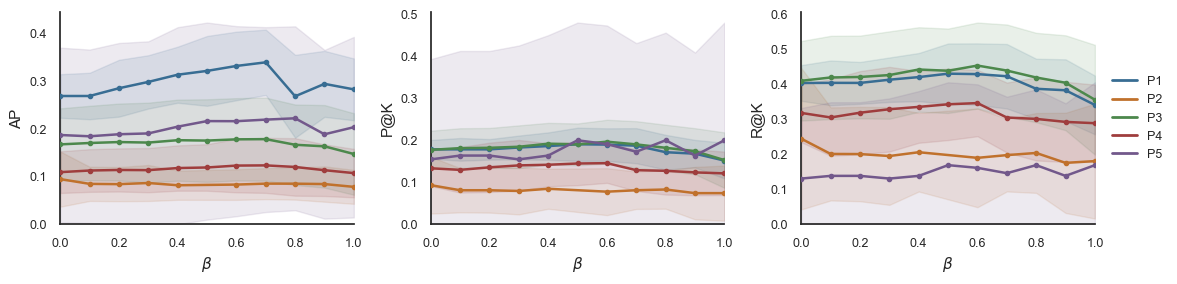

In [ ]:
records = parse_log(LOG_PATH)
# Remove any P2 entries coming from the main log
records = [r for r in records if r["pilot"] != "P2"]
# Parse the Baltanás-specific log and keep only P2
records.extend(
    r for r in parse_log(P2_LOG_PATH)
    if r["pilot"] == "P2"
)

print(f"Parsed {len(records)} blocks:")
for r in sorted(records, key=lambda x: (x["pilot"], x["beta"])):
    print(f"  {r['pilot']}  β={r['beta']:.1f}  "
          f"AP={r.get('AP_mean', float('nan')):.3f}±{r.get('AP_std', float('nan')):.3f}  "
          f"P@K={r.get('PK_mean', float('nan')):.3f}±{r.get('PK_std', float('nan')):.3f}  "
          f"R@K={r.get('RK_mean', float('nan')):.3f}±{r.get('RK_std', float('nan')):.3f}")

plot(records, save_path=SAVE_PATH)

# R3. Semantic module

### Intrinsic behaviour

In [ ]:
PILOT_CONFIG = {
    "Delos": {
        "data_path": "../data/Delos",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_models\final_june_delos\final_june.pt",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_models\final_june_baltanas\final_4dil_rmsbn16.pt",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_models\final_june_lucretili\final_june.pt",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_models\final_june_ranverso\final_june.pt",
    },
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_models\final_june_schenkenberg\final_june.pt",
    },
}



SITE_TH_DATA = {
        "delos": { 
            "R1a_rain_1h": 10, "R1b_rain_3h": 20,  
            "R2_wind": 12,
            "R3_hum_th": 75, "R3_cross": 9,  # delos perfect
        },
        "baltanas": { 
            "R1_ppv": 0.25, 
            "R2_hum_daily_range": 10, 
            "R3_gnss_change": 0.03, # 0.03 no act
            "R4a_soil_high": 67, # no act but leave
	        "R4b_soil_daily_range": 2, # 2 no act
            "R5a_airflow_const": 0.000001, # 0.0001 too many act 
	        "R5b_airflow_range": 6, # 
        },
        
        "lucretili": {
            "R1a_crack_step": 0.9, #0.6 too much
            "R1b_crack_offset": 0.6, # 0.5 too much
            "R2a_tilt_step": 0.9, # 0.2 too much
	        "R2b_tilt_offset": 0.6,  # 0.2 too much
            "R3_vib_zscore": 7,
            "R4a_hum_spike_6h": 97, "R4b_hum_persist_7d": 90, "R4c_hum_rapid_1h": 20, 
            "R5_visitors_peak": 30, # 25 too much
            "R6a_rain_1h": 5, "R6a_rain_24h": 20, # no active but leave
            "R6b_rain_cum7d": 100, # 7d: 70 too much
            "R7a_wind_peak_ratio": 15, 
            "R8_baro_range": 900, #700 too much
            "R9a_temp_lt": 20, # 15 too much:
            "R9b_temp_st": 5,
            "R10_solar_zscore": 3, # nothing but leave
        },
        "ranverso": {
            "R1_hum_inside": 80, 
            'R2_rain_7d_diff': 50, # 20 too much
            "R3_temp_nodiff": 1, # 2 nothing
            "R4a_soil_high": 60, # nothing but leave
	        "R4b_soil_low": 5,
        },
        "schenkenberg": {
            "R1_zerocross": 6, 
            "R1_hum_high": 90, 
            "R2_crack_step": 0.5, # 0.1 too much 
            "R3_vib_zscore": 5,  # 3 too much 
            "R4_pga": 5,  # 3 too much
            #"R5a_soil_high": 95,  "R5b_soil_range": 1,
        },
    }

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------------
# COLORS
# -----------------------------------
colors = {
    "AR": "#8954B8",
    "B": "#933838",
    "NS": "#54A68B"
}

# -----------------------------------
# METRIC MAPPING
# -----------------------------------
metric_cols = ["AR_orig", "B_orig", "S_orig"]

# -----------------------------------
# CONVERTER: iag -> DataFrame
# -----------------------------------
def diag_to_df(iag):

    rows = []

    for rule_name, metrics in iag.items():

        rows.append({
            "rule": rule_name,
            "AR_orig": metrics.get("activation_rate", np.nan),
            "B_orig": metrics.get("burstiness", np.nan),
            "S_orig": metrics.get("noise_sensitivity", np.nan),
        })

    return pd.DataFrame(rows)

END_DATE = "2026-06-30"


all_diag = []

for site_name, config in PILOT_CONFIG.items():

    thresholds = SITE_TH_DATA[site_name.lower()]
    print(f"\n===== Processing site: {site_name} =====")

    seed_everything(42)
    with suppress_all(): 
        base_dataset = pp.TimeSeriesData(
            config["data_path"],
            "30 min",
            True,
            threshold_overrides=thresholds
        )

        diag = base_dataset.compute_rule_diagnostics(
            base_dataset.ek_rules[2],
            base_dataset.ek_rules[1]
        )
    print(diag)

    # diag index = rule names
    tmp = diag.copy()

    tmp["rule"] = tmp.index
    tmp["site"] = site_name

    tmp = tmp.rename(columns={
        "activation_rate": "AR_orig",
        "burstiness": "B_orig",
        "noise_sensitivity": "S_orig"
    })

    all_diag.append(
        tmp[["site", "rule", "AR_orig", "B_orig", "S_orig"]]
    )



===== Processing site: Delos =====
              activation_rate  burstiness  noise_sensitivity
R1a_rain_1h          0.030846    0.708684           0.000476
R1b_rain_3h          0.053537    0.793890           0.000517
R2_wind              0.011305    0.521165           0.001712
R3_hum_cross         0.033834    0.894489           0.027519
R4_dates             0.001938   -0.147743           0.001575

===== Processing site: Baltanas =====
                    activation_rate  burstiness  noise_sensitivity
R1_ppv                     0.000760   -0.014289           0.000000
R2_hum_daily_range         0.087591    0.815530           0.037956
R3_gnss_change             0.000000         NaN           0.000000
R4a_soil_high              0.022202    0.734287           0.007877
R4b_soil_range             0.000000         NaN           0.000000
R5a_airflow_const          0.105839    0.824892           0.861314
R5b_airflow_range          0.000000         NaN           0.000000
R6_rain_1h             

            site                rule   AR_orig    B_orig    S_orig
19     Lucretili    R4a_hum_spike_6h  0.059219  0.790916  0.001129
20     Lucretili  R4b_hum_persist_7d  0.065934  0.854964  0.001832
21     Lucretili    R4c_hum_rapid_1h  0.048611  0.728926  0.007700
22     Lucretili         R5_visitors  0.166056  0.778200  0.028823
23     Lucretili            R6a_rain  0.000000       NaN  0.000000
24     Lucretili      R6b_rain_cum7d  0.165675  0.914576  0.000366
25     Lucretili             R7_wind  0.001297  0.192547  0.000229
26     Lucretili             R8_baro  0.115385  0.835430  0.020589
27     Lucretili         R9a_temp_lt  0.003663 -1.000000  0.001465
28     Lucretili         R9b_temp_st  0.008394  0.745680  0.004067
29     Lucretili    R10_solar_zscore  0.000000       NaN  0.000000
30      Ranverso       R1_hum_inside  0.059717  0.845643  0.010260
31      Ranverso          R2_rain_7d  0.157035 -0.139715  0.000057
32      Ranverso      R3_temp_nodiff  0.000000       NaN  0.00

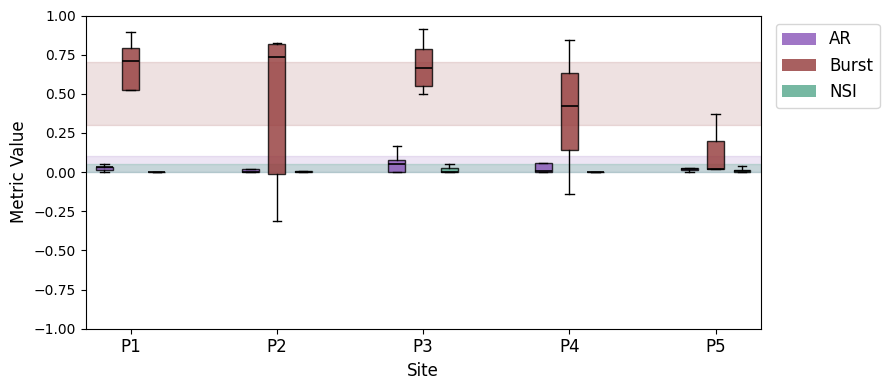

In [ ]:
df = pd.concat(all_diag, ignore_index=True)

print(df.tail(20))

metric_cols = ["AR_orig", "B_orig", "S_orig"]

site_order = [
    "Delos",
    "Baltanas",
    "Lucretili",
    "Ranverso",
    "Schenkenberg"
]
gap_info = [
    {
        "AR_low": 0.0,
        "AR_high": 0.2,

        "B_low": 0.3,
        "B_high": 0.7,

        "NS_low": 0.0,
        "NS_high": 0.05,
    }
]
# -----------------------------------
# BUILD GROUPED DATA
# -----------------------------------
groups = []
data = []

for site in site_order:

    subdf = df[df["site"] == site]

    if len(subdf) == 0:
        print(f"[WARN] empty site: {site}")
        continue

    groups.append(site)

    metric_data = []

    for col in metric_cols:

        vals = pd.to_numeric(subdf[col], errors="coerce").dropna().values

        print(site, col, "n =", len(vals))

        metric_data.append(vals)

    data.append(metric_data)

# -----------------------------------
# FLATTEN FOR BOXPLOT (THIS WAS MISSING)
# -----------------------------------
flat_data = []
positions = []

n_metrics = 3
within_spacing = 0.7
between_spacing = 1.8

for i, metric_data in enumerate(data):

    base = i * (n_metrics * within_spacing + between_spacing)

    for j in range(n_metrics):

        flat_data.append(metric_data[j])
        positions.append(base + j * within_spacing)

# DEBUG CHECK
print("\nFLAT DATA SIZES:")
for i, arr in enumerate(flat_data):
    print(i, len(arr))

# -----------------------------------
# PLOT
# -----------------------------------
fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    flat_data,
    positions=positions,
    patch_artist=True,
    showfliers=False,
    widths=0.45,
    medianprops=dict(color="black", linewidth=1.2)
)

# -----------------------------------
# COLORS
# -----------------------------------
for i, box in enumerate(bp["boxes"]):

    metric_idx = i % 3

    label = ["AR", "B", "NS"][metric_idx]

    box.set_facecolor(colors[label])
    box.set_alpha(0.8)

# -----------------------------------
# X LABELS
# -----------------------------------
centers = []

for i in range(len(groups)):

    base = i * (n_metrics * within_spacing + between_spacing)
    centers.append(base + (n_metrics - 1) * within_spacing / 2)

ax.set_xticks(centers)
ax.set_xticklabels([f"P{i+1}" for i in range(len(groups))], fontsize=12)

for g in gap_info:

    ax.axhspan(g["AR_low"], g["AR_high"]-0.1,
               color=colors["AR"], alpha=0.15)

    ax.axhspan(g["B_low"], g["B_high"],
               color=colors["B"], alpha=0.15)

    ax.axhspan(g["NS_low"], g["NS_high"],
               color=colors["NS"], alpha=0.25)


# -----------------------------------
# LEGEND
# -----------------------------------
legend = [
    Patch(facecolor=colors["AR"], label="AR", alpha=0.8),
    Patch(facecolor=colors["B"], label="Burst", alpha=0.8),
    Patch(facecolor=colors["NS"], label="NSI", alpha=0.8),
]

ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=12)

ax.set_ylabel("Metric Value", fontsize=12)
ax.set_xlabel("Site", fontsize=12)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

### Complementarity

In [ ]:
def evaluate_site(site_name, config, ths, device="cpu"):
    print(f"\n===== Processing site: {site_name} =====")

    seed_everything(42)

    with suppress_all():
        base_dataset = pp.TimeSeriesData(config["data_path"],"30 min",True, threshold_overrides= ths)
        pre_ds = pp.TSDataset("both",base_dataset.raw_df_with_alive.copy(),base_dataset.raw_df_with_alive.columns.tolist(), 
                            72, 0.1, 0.1,positive=base_dataset.ek_rules[0].max(axis=1))

        scale=pre_ds.feat_scale
        pre_ds.mode = "train"
        pre_ds.current_data = pre_ds.all_data["train"]
        train_loader= DataLoader(pre_ds, batch_size=256, shuffle=False) 
        pre_ds.mode = "val"
        pre_ds.current_data = pre_ds.all_data["val"]
        val_loader = DataLoader(pre_ds, batch_size=256,shuffle=False)
        pre_ds.mode = "test"
        pre_ds.current_data = pre_ds.all_data["test"]
        test_loader= DataLoader(pre_ds, batch_size=1, shuffle=False)
    
    print("total anomaly points", (base_dataset.ek_rules[0].max(axis=1) > 0.5).sum())
    model_args = { "data_dim": pre_ds.n_features,"hidden_dim": 32,"dropout": 0.3,}
    model = models.SerializableModule().create("NestedAD", **model_args)
    state_dict = torch.load( config["model_path"], map_location=device)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)

    train_scores, train_labels =    get_scores(model, train_loader, beta=0.5, revin=True, rec_refs=scale, fc_refs=scale, block_attn=False, block_tcn=False, return_outputs="labels")
    val_scores, val_labels =        get_scores(model, val_loader, beta=0.5, revin=True, rec_refs=scale, fc_refs=scale, block_attn=False,block_tcn=False,return_outputs="labels")
    test_scores, test_labels =      get_scores(model, test_loader, beta=0.5,revin=True, rec_refs=scale, fc_refs=scale, block_attn=False,block_tcn=False,return_outputs="labels")

    train_val_scores = np.concatenate([train_scores, val_scores],axis=0)
    threshold = compute_threshold(train_val_scores)

    all_scores = np.concatenate([train_scores, val_scores, test_scores], axis=0)
    all_labels_sem = np.concatenate( [train_labels, val_labels, test_labels], axis=0)
    all_labels_dl = (all_scores > threshold).astype(int)


    true_neg  = (all_labels_sem == 0) & (all_labels_dl == 0)
    sem_only  = (all_labels_sem == 1) & (all_labels_dl == 0)
    dl_only   = (all_labels_sem == 0) & (all_labels_dl == 1)
    both      = (all_labels_sem == 1) & (all_labels_dl == 1)
    
    print(true_neg.sum(), sem_only.sum(), dl_only.sum(), both.sum())

    # 1. Complementarity index (you already have this — proportion of semantic
    #    alarms missed by DL, i.e. sem_only / total_sem)
    comp_idx = sem_only.sum() / all_labels_sem.sum()

    # 2. Score percentile of semantic points within the FULL score distribution
    #    → if truly invisible to DL, semantic scores should sit at ~50th percentile
    #    → if redundant, they would sit at 90th+
    sem_scores    = all_scores[all_labels_sem == 1]
    all_scores_sorted = np.sort(all_scores)
    percentiles   = np.searchsorted(all_scores_sorted, sem_scores) / len(all_scores_sorted)
    median_pctile = np.median(percentiles)

    # 3. Effect size (Cohen's d) between sem=1 scores and true negatives
    #    → small effect size = DL genuinely doesn't see those events
    #    → avoids KS sample-size sensitivity
    mu_sem   = all_scores[sem_only].mean()
    mu_neg   = all_scores[true_neg].mean()
    std_pool = np.sqrt((all_scores[sem_only].var() + all_scores[true_neg].var()) / 2)
    cohens_d = (mu_sem - mu_neg) / (std_pool + 1e-8)

    print(f"Complementarity index : {comp_idx:.3f}")
    print(f"Median score percentile of semantic anomalies: {median_pctile:.3f}")
    print(f"Cohen's d (sem_only vs true-neg): {cohens_d:.3f}")


In [ ]:
for site_name, config in PILOT_CONFIG.items():
    thresholds = SITE_TH_DATA[site_name.lower()]
    evaluate_site(site_name, config, thresholds)

# EXTRA. Plots

### Injected anomalies examples

In [ ]:
def detect_periodic_features_multi(values, period_len, threshold=0.25):
    N, F = values.shape
    periodic_features = []

    for f in range(F):
        if N <= period_len:
            continue

        x = values[:, f]

        if np.std(x) < 1e-6:
            continue

        def autocorr(lag):
            if lag <= 0 or lag >= N:
                return 0
            x1 = x[:-lag]
            x2 = x[lag:]
            if np.std(x1) < 1e-6 or np.std(x2) < 1e-6:
                return 0
            return np.corrcoef(x1, x2)[0, 1]

        acf_p = autocorr(period_len)
        acf_half = autocorr(period_len // 2)
        acf_near = max(autocorr(period_len - period_len//6), autocorr(period_len + period_len//6))

        c1 = acf_p > threshold 
        c2 = acf_p > acf_half + 0.05
        c3 = acf_p > acf_near
        
        # periodicity condition
        if (c1 and c2 and c3):
            periodic_features.append(f)

    return periodic_features



def inject_controlled_anomalies(
    test_clean,
    lb=48,
    seed=42,
    sev=0.5,

):
    """
    Inject one anomaly per subtype using a minimal taxonomy:
    - Collective: shift, variance_burst, trend_flip
    - Contextual: context_swap (ONLY on periodic features)
    - Point: spike, drop
    """

    np.random.seed(seed)

    test_raw = test_clean.copy()
    N, F = test_raw.shape

    anomaly_indices = []

    # -----------------------------------------------------
    # choose stable features
    # -----------------------------------------------------
    feature_energy = np.std(test_clean, axis=0)
    valid_features = np.where(
        feature_energy > np.percentile(feature_energy, 20)
    )[0]

    # -----------------------------------------------------
    # contextual features must be periodic
    # -----------------------------------------------------
    periodic_features = detect_periodic_features_multi(test_clean, 24)
    print(periodic_features)

    # fallback: if no periodic features exist, skip contextual anomaly
    contextual_enabled = len(periodic_features) > 0

    # -----------------------------------------------------
    # subtype specification
    # -----------------------------------------------------
    specs = [
        # COLLECTIVE
        ("collective", "shift", 300),
        ("collective", "variance_burst", 700),
        ("collective", "frozen", 1100),
    ]

    # add contextual only if periodic features exist
    if contextual_enabled:
        specs.append(("contextual", "context_swap", 1490))

    # POINT
    specs.extend([
        ("point", "spike", 1900),
        ("point", "drop", 2300),
    ])

    # -----------------------------------------------------
    # inject
    # -----------------------------------------------------
    for idx, (atype, mode, center) in enumerate(specs):

        # choose feature
        if atype == "contextual":
            f = np.random.choice(periodic_features)
        else:
            f = valid_features[idx % len(valid_features)]

        local_std = np.std(
            test_clean[max(0, center - 100):center, f]
        ) + 1e-6

        # ---------------------------------------------
        # COLLECTIVE
        # ---------------------------------------------
        if atype == "collective":

            seg_len = 24
            s = center - seg_len // 2
            e = center + seg_len // 2
            seg = test_raw[s:e, f].copy()

            if mode == "shift":
                test_raw[s:e, f] = seg + 4 * sev * local_std
                print(f)

            elif mode == "variance_burst":
                noise = np.random.normal(0, 2 * sev * local_std, seg_len)
                test_raw[s:e, f] = seg + noise
                print(f)

            elif mode == "frozen":
                test_raw[s:e, f] = seg[0]
                print(f)

        # ---------------------------------------------
        # CONTEXTUAL (only periodic features)
        # ---------------------------------------------
        elif atype == "contextual":

            seg_len = 3
            s = center - 1
            e = center + 2
            if mode == "context_swap":

                f=12
                half_period = 24 // 2

                # choose +half or -half
                if np.random.rand() < 0.5:
                    donor_center = center + half_period
                else:
                    donor_center = center - half_period

                # clip to valid range
                donor_center = np.clip(donor_center, 1, N - 2)
                print(s, donor_center)

                # donor window of 3 points
                donor_window = test_raw[donor_center - 1 : donor_center + 2, f]

                # inject donor window
                test_raw[s:e, f] = donor_window

        # ---------------------------------------------
        # POINT
        # ---------------------------------------------
        elif atype == "point":

            s = center
            e = center + 1

            if mode == "spike":
                f=13
                test_raw[center, f] += 4 * sev * local_std
                print(f)

            elif mode == "drop":
                test_raw[center, f] -= 4 * sev * local_std
                print(f)

        # ---------------------------------------------
        # register anomaly
        # ---------------------------------------------
        anomaly_indices.append({
            "type": atype,
            "mode": mode,
            "start": s,
            "end": e,
            "center": center,
            "features": (f,),
        })

    return test_raw, anomaly_indices



# PLOT


def plot_one_per_subtype(
    test_clean,
    test_raw,
    anomaly_indices,
    lb=48,
):

    grouped = defaultdict(lambda: defaultdict(list))

    for a in anomaly_indices:
        grouped[a["type"]][a["mode"]].append(a)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    # =====================================================
    # ROW 1: 2 POINT + 1 CONTEXTUAL
    # =====================================================
    layout = [
        [
            ("collective", "shift"),
            ("collective", "variance_burst"),
            ("collective", "frozen"),
        ],
        [
            ("contextual", "context_swap"),
            ("point", "spike"),
            ("point", "drop"),
        ],
    ]

    for r, row in enumerate(layout):
        for c, (ttype, mode) in enumerate(row):

            ax = axes[r, c]

            entries = grouped[ttype].get(mode, [])
            if len(entries) == 0:
                ax.axis("off")
                continue

            entry = entries[0]

            start = max(0, entry["center"] - lb)
            end = min(test_raw.shape[0], entry["center"] + lb)

            x = np.arange(start, end)

            # clean
            ax.plot(
                x,
                test_clean[start:end, entry["features"][0]],
                linewidth=2,
                label="Original"
            )

            # injected
            ax.plot(
                x,
                test_raw[start:end, entry["features"][0]],
                linestyle="--",
                color="red",
                linewidth=2,
                label="Injected"
            )

            # anomaly region
            ax.axvspan(
                entry["start"],
                entry["end"],
                color="grey",
                alpha=0.2
            )
            ax.set_ylabel("Scaled feature value")
            ax.set_xlabel("Time point index")
            ax.set_title(f"{ttype}\n{mode}", fontsize=12)
            ax.grid(False)
            

    axes[1, 2].legend(fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:

pilot_sites = {"Delos": {  "data_path": "../data/Delos",},}


for site, paths in pilot_sites.items():
    print(f"\n===== Processing site: {site} =====")
    with suppress_all():
        data_path = paths["data_path"]
        base_dataset = pp.TimeSeriesData(data_path, "1h", True)
        pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive.values, base_dataset.feature_names, 72, 0.05, 0.9, positive=base_dataset.ek_rules[0].max(axis=1))
    test_clean = pre_ds.test_clean.copy()

    test_raw, anomaly_indices = inject_controlled_anomalies(
        test_clean,
        lb=48,
        seed=42,
    )

    plot_one_per_subtype(
        test_clean=test_clean,
        test_raw=test_raw,
        anomaly_indices=anomaly_indices,
        lb=48,
    )

### Dataset exploration

In [ ]:


pilot_sites = {
      "Delos": {
        "data_path": "../data/Delos",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },
}


all_datasets = {}

for site, paths in pilot_sites.items():
    print(f"\n===== Processing site: {site} =====")

    with suppress_all():
        device = "cpu"
        seed_everything(42)
        dataset = pp.TimeSeriesData(paths["data_path"],"1h", True,)
        all_datasets[site] = dataset
        
    print(dataset.feature_names)
    df = dataset.raw_df

    # Correlation matrix
    corr = df.corr(method="spearman")

    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):

            c1 = corr.columns[i]
            c2 = corr.columns[j]

            # Extract sensor IDs (first 6 chars before "_")
            sid1 = c1.split("_")[0]
            sid2 = c2.split("_")[0]

            # Skip same sensor
            if sid1 == sid2:
                continue

            val = corr.iloc[i, j]

            if pd.notna(val):
                pairs.append((c1, c2, val, abs(val)))

    # Sort by absolute correlation
    pairs = sorted(pairs, key=lambda x: x[3], reverse=True)

    print(f"\nTop 20 correlations for {site}:")
    for c1, c2, corr_val, _ in pairs[:20]:
            print(f"{corr_val:+.3f} | {c1} <-> {c2}")



In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr


time_windows = {
    "Delos": ("2026-01-15", "2026-02-15"),
    "Baltanas": ("2026-03-14", "2026-04-14"),
    "Lucretili": ("2026-03-20", "2026-04-20"),
    "Ranverso": ("2026-02-20", "2026-03-20"),
    "Schenkenberg": ("2026-05-24", "2026-06-22"),
}


selected_features = {
    "Delos": ["149368_h_masks_in_room215_2_soil_moisture", "151805_h_masks_in_room217_hum", "300548_rain_1", "800035_peoplecount",],
    "Baltanas": ["7020c8_temperatura mín.", "130432_c88_sisa_soil_temp", "4d7f09_v_in", "159313_c364_acc_ext_ppv_x",], 
    "Lucretili": ["177281_mont_hum", "153061_conv_tilt2_z","450308_counter_in",  "177310_mont_crack1"],
    "Ranverso": ["174188_in_back_hum", "143276_altar_tilt_x", "149361_out_pyran", "359111_pm10"],
    "Schenkenberg": ["300266_temp1", "152899_tilt2_x", "149796_crack", "152555_acc2_freq3y"],
}


feature_labels = {
    "Delos": {
        "149368_h_masks_in_room215_2_soil_moisture": "Soil moisture (%)",
        "151805_h_masks_in_room217_hum": "Humidity (%)",
        "300548_rain_1": "Rain (mm/h)",
        "800035_peoplecount": "People counter (#)",
    },
    "Baltanas": {
        "7020c8_temperatura mín.": "Temperature (ºC)",
        "130432_c88_sisa_soil_temp": "Internal Temp. (ºC)",
        "4d7f09_v_in": "Vehicle counter (#)",
        "159313_c364_acc_ext_ppv_x": "PPV (mm/s)",
    },
    "Lucretili": {
        "177281_mont_hum": "Humidity (%)",
        "153061_conv_tilt2_z": "Tiltmeter (º)",
        "450308_counter_in": "People counter (#)",
        "177310_mont_crack1": "Crackmeter (mm)",
    },
    "Ranverso": {
        "174188_in_back_hum": "Humidity (%)",
        "143276_altar_tilt_x": "Tiltmeter (º)",
        "149361_out_pyran": "Pyranometer (W/m²)",
        "359111_pm10": "PM10 (μg/m³)",
    },
    "Schenkenberg": {
        "300266_temp1": "Temperature (ºC)",
        "152899_tilt2_x": "Tiltmeter (º)",
        "149796_crack": "Crackmeter (mm)",
        "152555_acc2_freq3y": "PGA-Freq (Hz)",
    }
}



# --------------------------------------------------
# COLOR GROUPS
# --------------------------------------------------
green_features = {"Rain (mm/h)", "Humidity (%)", "Temperature (ºC)", "UV (W/m²)", "Bar. Pressure (hPa)", "Thermistor (ºC)", "Pyranometer (W/m²)", "PM10 (μg/m³)"}
blue_features = {"Soil moisture (%)", "Soil Moisture (%)", "PPV (mm/s)", "Crackmeter (mm)", "Tiltmeter (º)", "PGA-Freq (Hz)", "Internal Temp. (ºC)"}
royalblue_features = {"People counter (#)", "Vehicle counter (#)"}

def get_feature_color(label):
    if label in green_features:
        return "#58983A"
    elif label in blue_features:
        return "#2D9ECF"
    elif label in royalblue_features:
        return "#D47C10"
    return "black"

In [ ]:
import ruptures as rpt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

sites = list(selected_features.keys())

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(sites),
    figsize=(4 * len(sites), 8),
    sharex=False,
    constrained_layout=True
)

for col_idx, site in enumerate(sites):
    print(f"\n===== Processing site: {site} =====")
    print(f"Selected features: {selected_features[site][:4]}")

    dataset = all_datasets[site]
    df = dataset.raw_df.copy()
    df_alive = dataset.raw_df_with_alive.copy()

    start_time, end_time = time_windows[site]
    df_window = df.loc[start_time:end_time]
    df_alive_window = df_alive.loc[start_time:end_time]

    features = selected_features[site][:4]


    corr_matrix = np.full((len(features), len(features)), np.nan)

    for i, f1 in enumerate(features):
        for j, f2 in enumerate(features):

            tmp = df_window[[f1, f2]].dropna()

            if len(tmp) > 10:
                x = tmp[f1]
                y = tmp[f2]

                if isinstance(x, pd.DataFrame):
                    x = x.iloc[:, 0]
                if isinstance(y, pd.DataFrame):
                    y = y.iloc[:, 0]

                x = pd.to_numeric(x.values.ravel(), errors="coerce")
                y = pd.to_numeric(y.values.ravel(), errors="coerce")

                mask = np.isfinite(x) & np.isfinite(y)

                if mask.sum() > 10:
                    corr_matrix[i, j], _ = spearmanr(x[mask], y[mask])


    r12 = np.nan

    if len(features) >= 2:
        tmp = df_window[[features[0], features[1]]].dropna()

        if len(tmp) > 10:
            x = pd.to_numeric(tmp[features[0]], errors="coerce").to_numpy()
            y = pd.to_numeric(tmp[features[1]], errors="coerce").to_numpy()

            mask = np.isfinite(x) & np.isfinite(y)

            if mask.sum() > 10:
                r12, _ = spearmanr(x[mask], y[mask])


    # ==================================================
    # 3. CHANGE POINT DETECTION (GLOBAL)
    # ==================================================
    window = 20

    ns_vals = []

    for feat in features:
        s = pd.to_numeric(df_window[feat], errors="coerce")

        roll_mean = s.rolling(window).mean()
        roll_std = s.rolling(window).std()

        # how unstable stats are over time
        ns = roll_std.std() + roll_mean.std()
        ns_vals.append(ns)

    ns_index = np.nanmean(ns_vals)
    
    
    title_text = f"R(1,2) = {r12:.2f} | NS = {ns_index:.3f}"
    axes[0, col_idx].set_title(title_text, fontsize=12)


    # ==================================================
    # 4. PLOTTING (4 ROWS PER SITE)
    # ==================================================
    for row_idx in range(4):

        ax = axes[row_idx, col_idx]

        if row_idx >= len(features):
            ax.axis("off")
            continue

        feat = features[row_idx]
        label = feature_labels[site].get(feat, feat)
        color = get_feature_color(label)

        series = df_window[feat]
        if "tilt" in feat.lower():
            X=np.round(series / 90)
            series = series - X*90

        # --------------------------------------------------
        # GREY BACKGROUND (MISSING DATA ONLY)
        # --------------------------------------------------
        alive_col = f"{feat}_alive"

        if alive_col in df_alive_window.columns:
            dead_mask = (
                df_alive_window[alive_col]
                .reindex(df_window.index)
                .fillna(0)
                .eq(0)
                .to_numpy()
            )
        else:
            dead_mask = np.zeros(len(df_window), dtype=bool)

        ax.fill_between(
            df_window.index,
            0,
            1,
            where=dead_mask,
            transform=ax.get_xaxis_transform(),
            color="lightgrey",
            alpha=0.4,
            zorder=0
        )

        # --------------------------------------------------
        # SIGNAL
        # --------------------------------------------------
        ax.plot(
            df_window.index,
            series,
            color=color,
            linewidth=1.5,
            zorder=2
        )



        ax.set_xlim(df_window.index.min(), df_window.index.max())

        if row_idx == 3:
            ax.set_xlabel("Time", fontsize=12)
            ax.tick_params(axis="x", labelrotation=20)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
        ax.set_ylabel(label, fontsize=12)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# ==================================================
for col_idx, site in enumerate(sites):
    fig.text(
        (col_idx + 0.5) / len(sites),   # center of column
        -0.03,                          # below figure
        f"({chr(97 + col_idx)}) P{col_idx+1}",
        ha="center",
        va="top",
        fontsize=18,
        fontfamily="sans-serif",
        fontname="DejaVu Sans"
    )
plt.show()

### Case study

In [ ]:

pilot_sites = {"Baltanas": {  
    "data_path": "../data/Baltanas",
    "thresholds" : { # CHECK: rain thresholds to be fixed 
            "R1_ppv": 0.20, 
            "R2_hum_daily_range": 10, 
            "R3_gnss_change": 0.1, 
            "R4a_soil_high": 70, "R4b_soil_daily_range": 3,
            "R5a_airflow_const": 0.0001, 
            "R5b_airflow_range": 10, 
            "R6_rain_1h": 10
        },
    },
}


for site, config in pilot_sites.items():
    print(f"\n===== Processing site: {site} =====")

    device = "cpu"
    seed_everything(42)
    data_path = config["data_path"]
    thresholds = config["thresholds"]
    
    base_dataset = pp.TimeSeriesData(data_path,"30 min",True, threshold_overrides= thresholds)
    with suppress_all():
        pre_ds = pp.TSDataset("both",base_dataset.raw_df_with_alive.copy(),base_dataset.raw_df_with_alive.columns.tolist(), 
                            72, 0.1, 0.1,positive=base_dataset.ek_rules[0].max(axis=1), inject_on_init=False)
        
        scale=pre_ds.feat_scale
        pre_ds.mode = "train"
        pre_ds.current_data = pre_ds.all_data["train"]
        train_loader= DataLoader(pre_ds, batch_size=256, shuffle=False) 
        pre_ds.mode = "val"
        pre_ds.current_data = pre_ds.all_data["val"]
        val_loader = DataLoader(pre_ds, batch_size=256,shuffle=False)
        pre_ds.mode = "test"
        pre_ds.current_data = pre_ds.all_data["test"]
        test_loader= DataLoader(pre_ds, batch_size=1, shuffle=False)


===== Processing site: Baltanas =====
Using data from ../data/Baltanas
Baltanas truncated at 2026-04-14 23:59:59


C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
    

model_args = {"data_dim": pre_ds.n_features,"hidden_dim": 32,"dropout": 0.3,}

model = models.SerializableModule().create("NestedAD", **model_args)

state_dict = torch.load("C:\\Users\\Lidia\\GitHub\\Itefi_Argus\\models\\checkpoints\\final_models\\final_june_baltanas\\final_june.pt", map_location=device)


model.load_state_dict(state_dict,strict=False)
model.to(device)

train_scores = get_scores(model,train_loader,beta=0.5,revin=True, rec_refs=scale, fc_refs=scale, block_attn=False, block_tcn=False, return_outputs=None)
val_scores = get_scores(model,val_loader,beta=0.5,revin=True, rec_refs=scale, fc_refs=scale,  block_attn=False, block_tcn=False, return_outputs=None)
train_val_scores = np.concatenate([train_scores, val_scores], axis=0)
threshold1 = compute_threshold(train_val_scores)
print(f"Threshold (mad): {threshold1}")

threshold2 = np.percentile(train_val_scores, 99)
print(f"Threshold (99th percentile): {threshold2}")

test_scores, rec_last, fc_last = get_scores(model,test_loader,beta=0.5, revin=True, rec_refs=scale, fc_refs=scale, block_attn=False, block_tcn=False,return_outputs="preds",)

# ---------------- DATA ----------------
test_data = pre_ds.all_data["test"]
train_data = pre_ds.all_data["train"]

n_features = len(pre_ds.feature_names)
print(f"Number of features: {n_features}")
lb=72
test_scaled = test_data[lb:, :n_features]
test_alive  = test_data[lb:, n_features:]

train_scaled = train_data[lb:, :n_features]
train_alive  = train_data[lb:, n_features:]

feature_names = pre_ds.feature_names
for i in range(len(feature_names)): 
    print(i, feature_names[i])


Final threshold: 0.0708 

Threshold (mad): 0.07081326072710031
Threshold (99th percentile): 0.135693089713836
Number of features: 64
0 45720d_p_in
1 45720d_v_in
2 4d7f09_p_in
3 4d7f09_v_in
4 701ee3_humedad
5 701ee3_temperatura mín.
6 701ee3_temperatura máx.
7 7020c8_humedad
8 7020c8_temperatura mín.
9 7020c8_temperatura máx.
10 115666_c88_kitchen_soil_moisture
11 159347_c88_acc_int_ppv_x
12 159347_c88_acc_int_ppv_y
13 159347_c88_acc_int_ppv_z
14 159347_c88_acc_int_ppv_comp
15 159164_c88_acc_ext_ppv_x
16 159164_c88_acc_ext_ppv_y
17 159164_c88_acc_ext_ppv_z
18 159164_c88_acc_ext_ppv_comp
19 159313_c364_acc_ext_ppv_x
20 159313_c364_acc_ext_ppv_y
21 159313_c364_acc_ext_ppv_z
22 159313_c364_acc_ext_ppv_comp
23 168762_gnss_onesample_altitude
24 168762_gnss_onesample_latitude
25 168762_gnss_onesample_longitude
26 168762_gnss_short_term_altitude
27 168762_gnss_short_term_latitude
28 168762_gnss_short_term_longitude
29 168762_gnss_long_term_longitude
30 168762_gnss_long_term_latitude
31 168762_

In [ ]:
test_scores = np.asarray(test_scores).flatten()
test_scores = np.abs(test_scores[:-1])
test_scores = np.nan_to_num(test_scores, nan=0.0, posinf=0.0, neginf=0.0)

n_maskable = train_alive.shape[1]
print(f"n_features (real, total): {n_features}")
print(f"n_maskable (real features with alive tracking): {n_maskable}")

rec_diff = np.abs(test_scaled[:-1, :n_maskable] - rec_last)
fc_diff  = np.abs(test_scaled[:-1, :n_maskable] - fc_last)

test_inv = np.zeros_like(test_scaled)
rec_last_inv = np.zeros_like(rec_last)
fc_last_inv  = np.zeros_like(fc_last)

for f in range(n_maskable):
    scaler_f = pre_ds.fitted_scalers.get(f)
    if scaler_f is None:
        test_inv[:, f] = test_scaled[:, f]
        rec_last_inv[:, f] = rec_last[:, f]
        fc_last_inv[:, f] = fc_last[:, f]
        continue

    test_inv[:, f] = scaler_f.inverse_transform(test_scaled[:, f].reshape(-1, 1)).flatten()
    rec_last_inv[:, f] = scaler_f.inverse_transform(rec_last[:, f].reshape(-1, 1)).flatten()
    fc_last_inv[:, f]  = scaler_f.inverse_transform(fc_last[:, f].reshape(-1, 1)).flatten()

T = min(len(test_inv), len(test_scores), len(rec_last_inv), len(fc_last_inv))

test_inv     = test_inv[:T]
test_scores  = test_scores[:T]
rec_last_inv = rec_last_inv[:T]
fc_last_inv  = fc_last_inv[:T]
rec_diff     = rec_diff[:T]
fc_diff      = fc_diff[:T]

x = np.arange(T)

start_T = 50 #25
end_T = 150 #200
x_w = np.arange(start_T, end_T)
threshold = threshold1*1.05
anomaly_mask_full = test_scores > threshold

rules_to_exclude = ["R6_rain_1h"] #["R5a_airflow_const"]

ek_df_full = base_dataset.ek_rules[0]
ek_df = ek_df_full.iloc[pre_ds.test_idx].copy()

# Remove excluded rules from all subsequent semantic analysis
rules_available = [
    rule for rule in ek_df.columns
    if rule not in rules_to_exclude
]

ek_df = ek_df[rules_available]

ek_raw = ek_df.max(axis=1).to_numpy()
sem_mask = ek_raw > 0.5
sem_counts = (ek_df > 0.5).sum(axis=1).to_numpy()

print("EK raw > 0.5 (full test):", np.sum(sem_mask))
print("Distinct active-rule counts:", np.unique(sem_counts))

RULE_DESCRIPTIONS = {
    "R1_PPV": "PPV > 0.25 mm/s",
    "R2_hum_daily_range": "Hum range > 10 %",
    "R5a_airflow_const": "Airflow range < 0.1 m/s",
    # "R1a_rain_1h": "Rain (1h) > 10 mm",
    # "R1b_rain_3h": "Rain (3h) > 20 mm",
    # "R3_hum_th": "Humidity > 75%",
}



def pretty_rule(name):
    return RULE_DESCRIPTIONS.get(name, name)

feature_names = list(pre_ds.feature_names[:n_maskable])

include_indices = [3, 12, 51, 33, 55]
pretty_names = {
    2:  "People counter (#)",
    3:  "Vehicle counter (#)",

    4:  "701ee3 Hum",
    5:  "701ee3 Tem min.",
    6:  "701ee3 Tem max.",
    7:  "7020c8 Hum",
    8:  "7020c8 Tem min.",
    9:  "7020c8 Tem max.",

    11: "PPV_int_x (mm/s)",
    12: "PPV_int_y (mm/s)",
    13: "PPV_int_z (mm/s)",
    14: "PPV_int (mm/s)",
    

    15: "PPV_ext_x_1",
    16: "PPV_ext_y_1",
    17: "PPV_ext_z_1",
    18: "PPV_ext_1",

    19: "PPV_ext_x",
    20: "PPV_ext_y",
    21: "PPV_ext_z",
    22: "PPV_ext",

    29: "GNSS 1d long",
    30: "GNSS 1d lat",
    31: "GNSS 1d alt",

    32: "Airflow_1",
    33: "Airflow S2 (m/s)",
    34: "Airflow_3",

    38: "Airflow_4",

    43: "PPV_int_freq_x (Hz)",
    44: "PPV_int_freq_y (Hz)",
    45: "PPV_int_freq_z (Hz)",

    46: "PPV_ext_freq_x S1",
    47: "PPV_ext_freq_y S1",
    48: "PPV_ext_freq_z ",

    49: "PPV_ext_freq_x",
    50: "PPV_ext_freq_y",
    51: "PPV_ext_freq_z",

    52: "caa416 Hum",
    53: "caa416 Tem min.",
    54: "caa416 Tem max.",

    55: "Hum S1 (%)",
    56: "caa50b Tem min.",
    57: "caa50b Tem max.",
}
for idx, name in pretty_names.items():
    if idx < len(feature_names):
        feature_names[idx] = name

print("\nFeature index reference (use this to pick include_indices):")
for i, name in enumerate(feature_names):
    print(i, name)

feat_scores = rec_diff + fc_diff  # shape (T, n_maskable)

def get_intervals(mask, t_start, t_end):
    intervals = []
    inside = False
    s = None
    for t in range(t_start, t_end):
        if mask[t] and not inside:
            s = t
            inside = True
        elif (not mask[t]) and inside:
            intervals.append((s, t - 1))
            inside = False
    if inside:
        intervals.append((s, t_end - 1))
    return intervals


def explain_dl_interval(s, e, top_k=3):
    mean_feat = feat_scores[s:e + 1].mean(axis=0)
    contrib = mean_feat / (mean_feat.sum() + 1e-8)
    top_idx = np.argsort(contrib)[::-1][:top_k]

    score = test_scores[s:e + 1].max()
    tail = train_val_scores[train_val_scores > threshold]
    tau = tail.std() if len(tail) > 1 else 1e-8
    tau = max(tau, 1e-8)
    delta = max(score - threshold, 0)
    conf = 0.5 + 0.5 * (1 - np.exp(-delta / tau))

    return {
        "start": s, "end": e,
        "confidence": conf,
        "top_idx": top_idx,
        "features": [feature_names[k] for k in top_idx],
        "contrib": contrib,
    }


def explain_sem_interval(s, e):
    lb_offset = 72
    rule_mean = ek_df.iloc[s + lb_offset: e + 1 + lb_offset].mean(axis=0)
    active = rule_mean[rule_mean > 0.5]
    return {
        "start": s, "end": e,
        "confidence": active.max() if len(active) else 0.0,
        "rules": active.sort_values(ascending=False).index[:3].tolist(),
        "rule_scores": active,
    }


dl_intervals_full = get_intervals(anomaly_mask_full, 0, T)
dl_info_full = [explain_dl_interval(s, e) for s, e in dl_intervals_full]

lb_offset = 72
sem_valid_end = min(T, len(sem_mask) - lb_offset)
sem_shifted_mask = sem_mask[lb_offset: lb_offset + sem_valid_end]
sem_intervals_full = get_intervals(sem_shifted_mask, 0, sem_valid_end)
sem_info_full = [explain_sem_interval(s, e) for s, e in sem_intervals_full]

dl_info = [info for info in dl_info_full if info["end"] >= start_T and info["start"] < end_T]
sem_info = [info for info in sem_info_full if info["end"] >= start_T and info["start"] < end_T]

print(f"\nDL intervals in window [{start_T},{end_T}): {len(dl_info)} "
      f"(full test set: {len(dl_info_full)})")
print(f"SEM intervals in window [{start_T},{end_T}): {len(sem_info)} "
      f"(full test set: {len(sem_info_full)})")

for info in dl_info:
    print(f"\n[DL] t=({info['start']},{info['end']})  CS={info['confidence']:.3f}")
    for name in info["features"]:
        print(f"   - {name}")

for info in sem_info:
    print(f"\n[SEM] t=({info['start']},{info['end']})  CS={info['confidence']:.3f}")
    for name in info["rules"]:
        print(f"   - {pretty_rule(name)}")

global_importance = np.zeros(n_maskable)

for info in dl_info_full:
    global_importance += info["contrib"] * info["confidence"]

order = np.argsort(global_importance)[::-1]
total = global_importance.sum() + 1e-12

print("\n===== GLOBAL FEATURE RESPONSIBILITY (all DL anomalies, full test set) =====")
for k in order:
    if global_importance[k] <= 0:
        continue
    print(f"{feature_names[k]:20s}  weight={global_importance[k]:.4f}  "
          f"share={global_importance[k] / total:.1%}")

sem_rule_weight = {}
for info in sem_info_full:
    for rule_name, val in info["rule_scores"].items():
        sem_rule_weight[rule_name] = sem_rule_weight.get(rule_name, 0.0) + val

print("\n===== GLOBAL SEM RULE RESPONSIBILITY (all SEM anomalies, full test set) =====")
for rule_name, w in sorted(sem_rule_weight.items(), key=lambda kv: -kv[1]):
    print(f"{pretty_rule(rule_name):30s}  weight={w:.4f}")


n_features (real, total): 64
n_maskable (real features with alive tracking): 58
EK raw > 0.5 (full test): 98
Distinct active-rule counts: [0 2 3]

Feature index reference (use this to pick include_indices):
0 45720d_p_in
1 45720d_v_in
2 People counter (#)
3 Vehicle counter (#)
4 701ee3 Hum
5 701ee3 Tem min.
6 701ee3 Tem max.
7 7020c8 Hum
8 7020c8 Tem min.
9 7020c8 Tem max.
10 115666_c88_kitchen_soil_moisture
11 PPV_int_x (mm/s)
12 PPV_int_y (mm/s)
13 PPV_int_z (mm/s)
14 PPV_int (mm/s)
15 PPV_ext_x_1
16 PPV_ext_y_1
17 PPV_ext_z_1
18 PPV_ext_1
19 PPV_ext_x
20 PPV_ext_y
21 PPV_ext_z
22 PPV_ext
23 168762_gnss_onesample_altitude
24 168762_gnss_onesample_latitude
25 168762_gnss_onesample_longitude
26 168762_gnss_short_term_altitude
27 168762_gnss_short_term_latitude
28 168762_gnss_short_term_longitude
29 GNSS 1d long
30 GNSS 1d lat
31 GNSS 1d alt
32 Airflow_1
33 Airflow S2 (m/s)
34 Airflow_3
35 149443_c88_atm_press
36 177322_c88_path_soil_moisture
37 149265_c88_sisa_soil_moisture
38 Airflow_

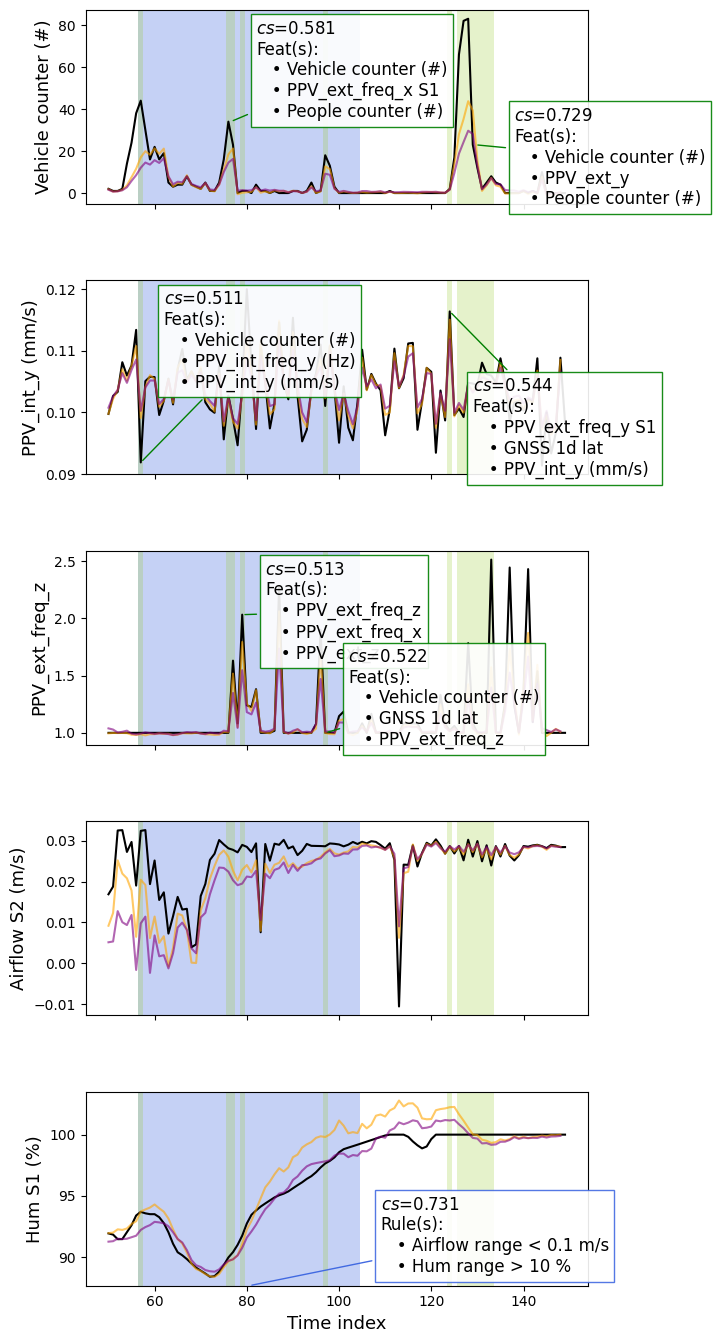

In [ ]:
# ----------------------------------------------------------------------
# CONFIGURACIÓN DE ESPACIO ENTRE SUBPLOTS (en cm)
# ----------------------------------------------------------------------
GAP_CM = 2.8
SUBPLOT_HEIGHT_INCH = 2.8

gap_in = GAP_CM / 2.54
n_feat = len(include_indices)
fig_height = n_feat * SUBPLOT_HEIGHT_INCH + (n_feat - 1) * gap_in
hspace = gap_in / SUBPLOT_HEIGHT_INCH


fig, axes = plt.subplots(n_feat, 1, figsize=(7.2*0.9, fig_height*0.9), sharex=True)

if n_feat == 1:
    axes = [axes]

plt.subplots_adjust(hspace=hspace)

# ----------------------------------------------------------------------
# Resto de configuraciones
# ----------------------------------------------------------------------
axis_of_feat = {feat_idx: ax for feat_idx, ax in zip(include_indices, axes)}

WIND_SPEED_IDX = 6
sem_target_ax = axis_of_feat.get(WIND_SPEED_IDX, axes[-1])

ANNOT_FONTSIZE = 12
BOX_X_OFFSET = 5
MIN_X_GAP = 90
LANE_STEP_FRAC = 0.45

def sem_alpha(n_rules):
    base_alpha = 0.25
    if n_rules <= 1:
        return base_alpha
    return min(base_alpha + 0.20 * (n_rules - 1), 0.85)

def assign_lanes(items, min_gap):
    lanes_last_x = []
    lane_idx = []
    for it in items:
        placed = False
        for lane, last_x in enumerate(lanes_last_x):
            if it["x"] - last_x >= min_gap:
                lanes_last_x[lane] = it["x"]
                lane_idx.append(lane)
                placed = True
                break
        if not placed:
            lanes_last_x.append(it["x"])
            lane_idx.append(len(lanes_last_x) - 1)
    return lane_idx

# ----------------------------------------------------------------------
# Dibujar señales y fondos de intervalos
# ----------------------------------------------------------------------
for ax, i in zip(axes, include_indices):
    for t in range(start_T, end_T):
        ek_idx = t + lb_offset
        if 0 <= ek_idx < len(sem_mask) and sem_mask[ek_idx]:
            alpha_val = sem_alpha(int(sem_counts[ek_idx]))/1.5
            ax.axvspan(t - 0.5, t + 0.5, color="royalblue", alpha=alpha_val, linewidth=0)

    start = None
    for t in range(start_T, end_T):
        if anomaly_mask_full[t] and start is None:
            start = t
        elif not anomaly_mask_full[t] and start is not None:
            ax.axvspan(start - 0.5, t - 0.5, color="yellowgreen", alpha=0.25, linewidth=0)
            start = None
    if start is not None:
        ax.axvspan(start - 0.5, end_T - 0.5, color="yellowgreen", alpha=0.25, linewidth=0)

    ax.plot(x_w, test_inv[start_T:end_T, i], color="black", label="Signal", linewidth=1.5, zorder=10)
    ax.plot(x_w[:-1], rec_last_inv[start_T + 1:end_T, i], color="orange", alpha=0.6,
            label="Reconstruction", zorder=10)
    ax.plot(x_w[:-1], fc_last_inv[start_T + 1:end_T, i], color="purple", alpha=0.6,
            label="Forecast", zorder=10)

    ax.set_ylabel(pretty_names.get(i, feature_names[i]), fontsize=13)

# ----------------------------------------------------------------------
# Anotaciones DL: asignación fija [1,0,2,2,1,0]
# ----------------------------------------------------------------------
# Mapeo fijo: 1ª→eje2, 2ª→eje1, 3ª→eje3, 4ª→eje3, 5ª→eje2, 6ª→eje1
# En índices 0‑based: [1, 0, 2, 2, 1, 0]
base_pattern = [1, 0, 2, 2, 1, 0]
n_dl = len(dl_info)
axis_pattern = (base_pattern * ((n_dl // 6) + 1))[:n_dl]   # se adapta al número real de anotaciones

dl_by_axis = {0: {"ax": axes[0], "items": []},
              1: {"ax": axes[1], "items": []},
              2: {"ax": axes[2], "items": []}}

for idx, info in enumerate(dl_info):
    target_axis_idx = axis_pattern[idx]
    target_ax = axes[target_axis_idx]
    target_feat_idx = include_indices[target_axis_idx]
    xc = (info["start"] + info["end"]) / 2
    x_box = min(info["end"] + BOX_X_OFFSET, end_T - 5)
    dl_by_axis[target_axis_idx]["items"].append({
        "x": x_box,
        "xc": xc,
        "info": info,
        "feat_idx": target_feat_idx
    })

# Dibujar anotaciones DL
for axis_idx, group in dl_by_axis.items():
    target_ax = group["ax"]
    items = sorted(group["items"], key=lambda d: d["x"])
    if not items:
        continue
    lanes = assign_lanes(items, MIN_X_GAP)
    ymin, ymax = target_ax.get_ylim()
    feat_idx = include_indices[axis_idx]
    y_series = test_inv[start_T:end_T, feat_idx]

    for it, lane in zip(items, lanes):
        info = it["info"]
        xc_local = int(np.clip(it["xc"] - start_T, 0, len(y_series) - 1))
        y_target = y_series[xc_local]
        y_box = ymax - (0.05 + lane * LANE_STEP_FRAC) * (ymax - ymin)
        feat_txt = "\n".join([f"   • {f}" for f in info["features"]])
        txt = (rf"$\it{{cs}}$={info['confidence']:.3f}" "\nFeat(s):" f"\n{feat_txt}")
        target_ax.annotate(txt,
                           xy=(it["xc"], y_target),
                           xytext=(it["x"], y_box),
                           fontsize=ANNOT_FONTSIZE,
                           ha="left",
                           va="top",
                           bbox=dict(facecolor="white", edgecolor="green", alpha=0.9),
                           arrowprops=dict(arrowstyle="-", color="green", lw=1),
                           zorder=50)

# ----------------------------------------------------------------------
# Anotaciones SEM (solo en sem_target_ax)
# ----------------------------------------------------------------------
sem_items = []
for info in sem_info:
    xc = (info["start"] + info["end"]) / 2
    x_box = min(info["end"] + BOX_X_OFFSET, end_T - 5)
    sem_items.append({"x": x_box, "xc": xc, "info": info})

sem_items = sorted(sem_items, key=lambda d: d["x"])
sem_lanes = assign_lanes(sem_items, MIN_X_GAP)
ymin, ymax = sem_target_ax.get_ylim()

for it, lane in zip(sem_items, sem_lanes):
    info = it["info"]
    y_box = ymin + (0.05 + lane * LANE_STEP_FRAC) * (ymax - ymin)
    rule_txt = "\n".join([f"   • {pretty_rule(r)}" for r in info["rules"]])
    txt = (rf"$\it{{cs}}$={info['confidence']:.3f}" "\nRule(s):" f"\n{rule_txt}")
    sem_target_ax.annotate(txt,
                           xy=(it["xc"], ymin),
                           xytext=(it["x"], y_box),
                           fontsize=ANNOT_FONTSIZE,
                           ha="left",
                           va="bottom",
                           bbox=dict(facecolor="white", edgecolor="royalblue", alpha=0.9),
                           arrowprops=dict(arrowstyle="-", color="royalblue", lw=1),
                           zorder=50)

# ----------------------------------------------------------------------
# Leyenda y etiquetas finales
# ----------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color="yellowgreen", alpha=0.25, label=r"$y^{DL} = 1$"),
    mpatches.Patch(color="royalblue", alpha=0.25, label=r"$y^{SEM} = 1$"),
    plt.Line2D([0], [0], color="black", label="Signal"),
    plt.Line2D([0], [0], alpha=0.6, color="orange", label="Reconstruction"),
    plt.Line2D([0], [0], alpha=0.6, color="purple", label="Forecast"),
]

axes[-1].set_xlabel("Time index", fontsize=13)
plt.show()